# 🏦 Loan Approval Prediction Project

## 🎯 Objective:
Predict whether a loan application will be approved or rejected based on applicant details.

## 📊 Type:
Binary Classification Problem

## 🎯 Target Variable:
Loan_Status (Y = Approved, N = Rejected)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [5]:
df = pd.read_csv('loan_classification.csv')

### BASIC DATA UNDERSTANDING

In [7]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LN000000,Male,No,0,Not Graduate,No,2000,1150,248,240,1,Semiurban,Y
1,LN000001,Female,Yes,1,Graduate,No,12838,5322,700,120,0,Urban,N
2,LN000002,Male,Yes,2,Graduate,No,4698,1138,308,360,1,Urban,Y
3,LN000003,Male,No,2,Graduate,No,9064,391,700,240,1,Urban,Y
4,LN000004,Male,Yes,2,Graduate,No,3519,3322,344,360,1,Rural,Y


In [8]:
df.shape

(100000, 13)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Loan_ID            100000 non-null  object
 1   Gender             100000 non-null  object
 2   Married            100000 non-null  object
 3   Dependents         100000 non-null  object
 4   Education          100000 non-null  object
 5   Self_Employed      100000 non-null  object
 6   ApplicantIncome    100000 non-null  int64 
 7   CoapplicantIncome  100000 non-null  int64 
 8   LoanAmount         100000 non-null  int64 
 9   Loan_Amount_Term   100000 non-null  int64 
 10  Credit_History     100000 non-null  int64 
 11  Property_Area      100000 non-null  object
 12  Loan_Status        100000 non-null  object
dtypes: int64(5), object(8)
memory usage: 9.9+ MB


In [14]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,5562.326190,2485.463500,642.264330,275.908200,0.750180
std,2934.622776,2293.885216,117.390743,89.762207,0.432911
min,2000.000000,63.000000,125.000000,120.000000,0.000000
25%,3492.000000,1051.000000,665.000000,180.000000,1.000000
50%,4895.000000,1808.000000,700.000000,240.000000,1.000000
75%,6872.000000,3108.000000,700.000000,360.000000,1.000000
max,25000.000000,20000.000000,700.000000,360.000000,1.000000


In [17]:
df.nunique()

Loan_ID              100000
Gender                    2
Married                   2
Dependents                4
Education                 2
Self_Employed             2
ApplicantIncome       12347
CoapplicantIncome      9903
LoanAmount              573
Loan_Amount_Term          4
Credit_History            2
Property_Area             3
Loan_Status               2
dtype: int64

In [19]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### TARGET ANALYSIS

In [24]:
df['Loan_Status'].value_counts()

Loan_Status
Y    72470
N    27530
Name: count, dtype: int64

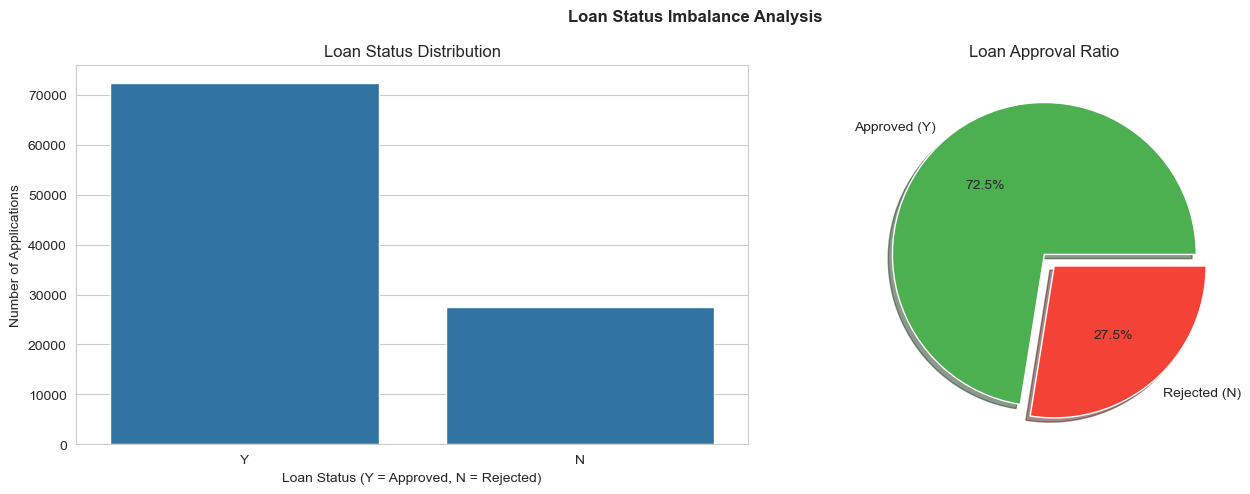

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# -----------------------
# Countplot
# -----------------------
sns.countplot(x='Loan_Status', data=df, ax=ax[0])
ax[0].set_title('Loan Status Distribution')
ax[0].set_xlabel('Loan Status (Y = Approved, N = Rejected)')
ax[0].set_ylabel('Number of Applications')

# -----------------------
# Pie Chart
# -----------------------
df['Loan_Status'].value_counts().plot.pie(
    explode=[0, 0.1],
    autopct='%1.1f%%',
    ax=ax[1],
    shadow=True,
    colors=['#4CAF50', '#F44336'],
    labels=['Approved (Y)', 'Rejected (N)']
)

ax[1].set_title('Loan Approval Ratio')
ax[1].set_ylabel('')

plt.suptitle('Loan Status Imbalance Analysis', weight='bold')
plt.tight_layout()
plt.show()

# 📊 Univariate Analysis (Single Variable Study)

## 🎯 Why do we need Univariate Analysis?

Univariate analysis helps us understand:
- Distribution of each feature
- Skewness (left/right bias)
- Outliers in data
- Type of data (normal or not)

👉 It answers: "What is happening inside each column?"

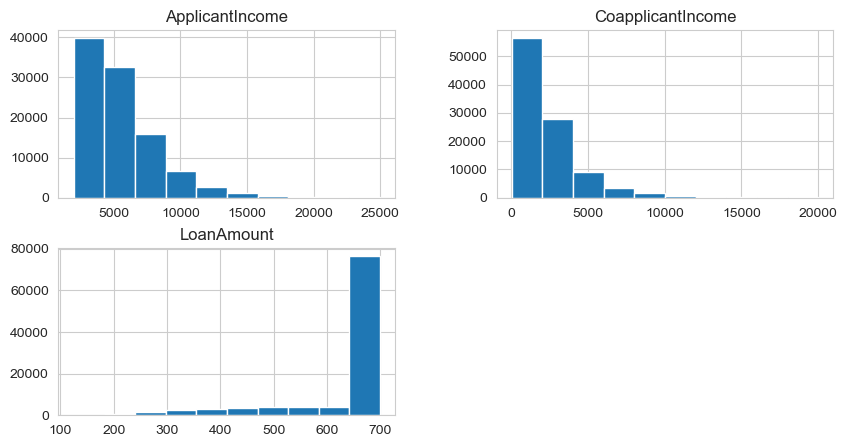

In [30]:
df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']].hist(figsize=(10,5))
plt.show()

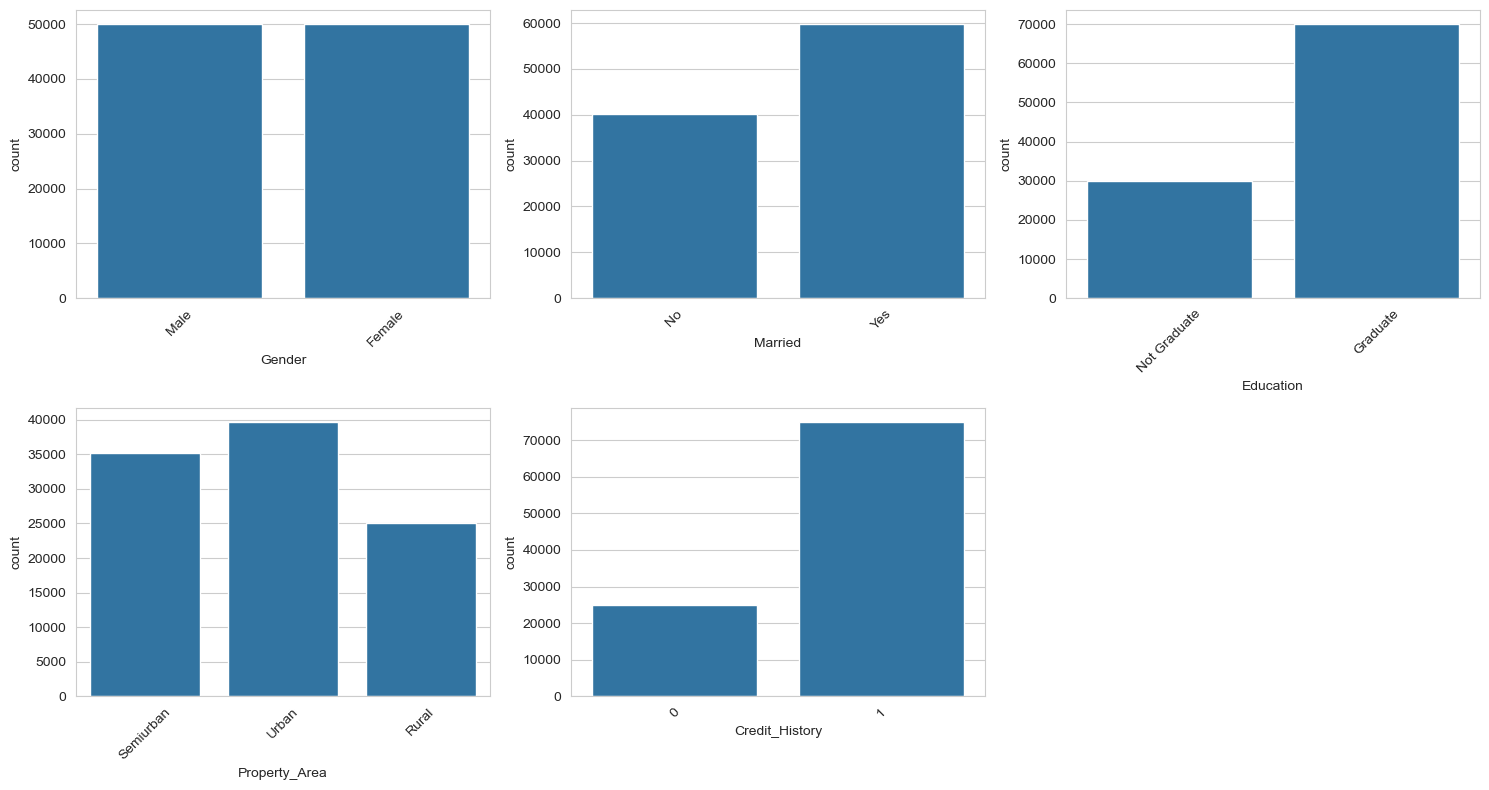

In [33]:
cat_cols = ['Gender','Married','Education','Property_Area','Credit_History']

plt.figure(figsize=(15,8))
for i,col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 📊 Bivariate Analysis (Feature vs Target)

## 🎯 Why do we need Bivariate Analysis?

Bivariate analysis helps us:
- Understand relationship between input and target
- Find which features affect loan approval
- Identify strong vs weak predictors
- Improve feature selection for model

👉 It answers: "What affects loan approval?"

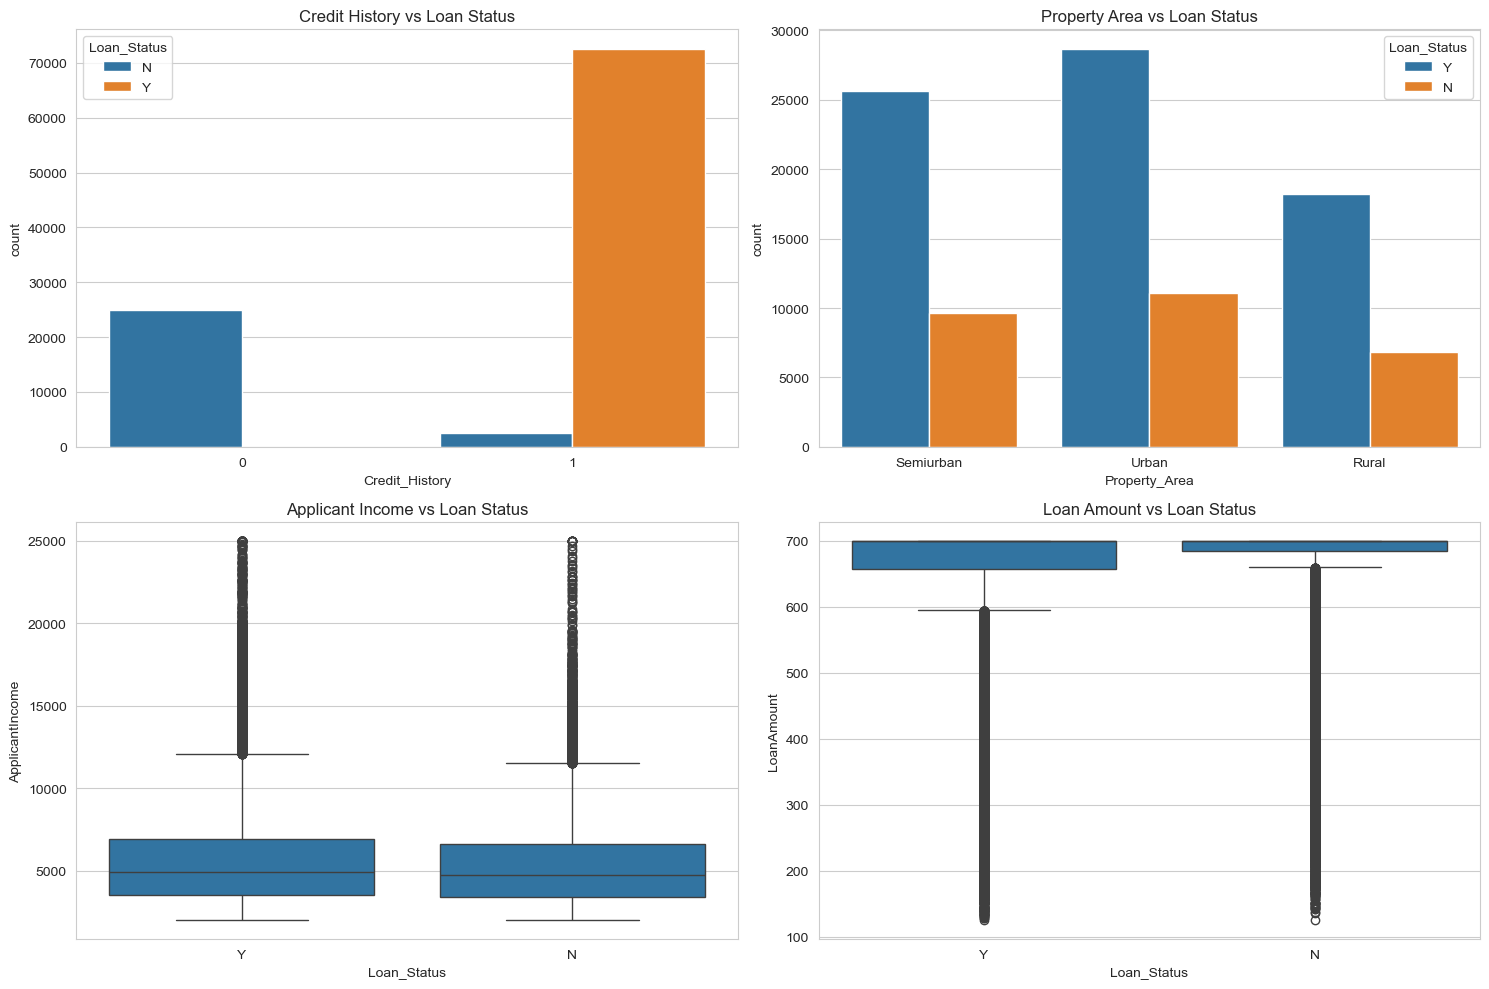

In [36]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# -----------------------
# 1. Credit History vs Loan Status
# -----------------------
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, ax=ax[0, 0])
ax[0, 0].set_title('Credit History vs Loan Status')

# -----------------------
# 2. Property Area vs Loan Status
# -----------------------
sns.countplot(x='Property_Area', hue='Loan_Status', data=df, ax=ax[0, 1])
ax[0, 1].set_title('Property Area vs Loan Status')

# -----------------------
# 3. Applicant Income vs Loan Status
# -----------------------
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df, ax=ax[1, 0])
ax[1, 0].set_title('Applicant Income vs Loan Status')

# -----------------------
# 4. Loan Amount vs Loan Status
# -----------------------
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df, ax=ax[1, 1])
ax[1, 1].set_title('Loan Amount vs Loan Status')

plt.tight_layout()
plt.show()

### 📌 Boxplot Conclusion

- Income does not strongly affect loan approval  
- Loan Amount also has weak impact on approval  
- Both features have many outliers  
- Approved and rejected cases overlap a lot  
- Credit History is more important than income or loan amount  

### 🧹 Data Cleaning

## 🎯 Why do we clean data?

- Machine learning models cannot handle missing values directly
- Dirty data reduces model accuracy
- Incorrect data types can break models
- Cleaning improves prediction quality

👉 Clean data = Better model performance

In [43]:
df.drop('Loan_ID', axis=1, inplace=True)

In [45]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [47]:
df.duplicated().sum()

1

In [49]:
# Remove duplicate rows
df = df.drop_duplicates()

# Verify
print("Duplicate Rows After Removal:", df.duplicated().sum())

Duplicate Rows After Removal: 0


In [51]:
df.nunique()

Gender                   2
Married                  2
Dependents               4
Education                2
Self_Employed            2
ApplicantIncome      12347
CoapplicantIncome     9903
LoanAmount             573
Loan_Amount_Term         4
Credit_History           2
Property_Area            3
Loan_Status              2
dtype: int64

In [53]:
df.dtypes

Gender               object
Married              object
Dependents           object
Education            object
Self_Employed        object
ApplicantIncome       int64
CoapplicantIncome     int64
LoanAmount            int64
Loan_Amount_Term      int64
Credit_History        int64
Property_Area        object
Loan_Status          object
dtype: object

In [55]:
num_cols = df.select_dtypes(include=['int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,99999.0,5562.361814,2934.615827,2000.0,3492.0,4895.0,6872.0,25000.0
CoapplicantIncome,99999.0,2485.474895,2293.893855,63.0,1051.0,1808.0,3108.0,20000.0
LoanAmount,99999.0,642.263753,117.391188,125.0,665.0,700.0,700.0,700.0
Loan_Amount_Term,99999.0,275.908559,89.762584,120.0,180.0,240.0,360.0,360.0
Credit_History,99999.0,0.750178,0.432912,0.0,1.0,1.0,1.0,1.0


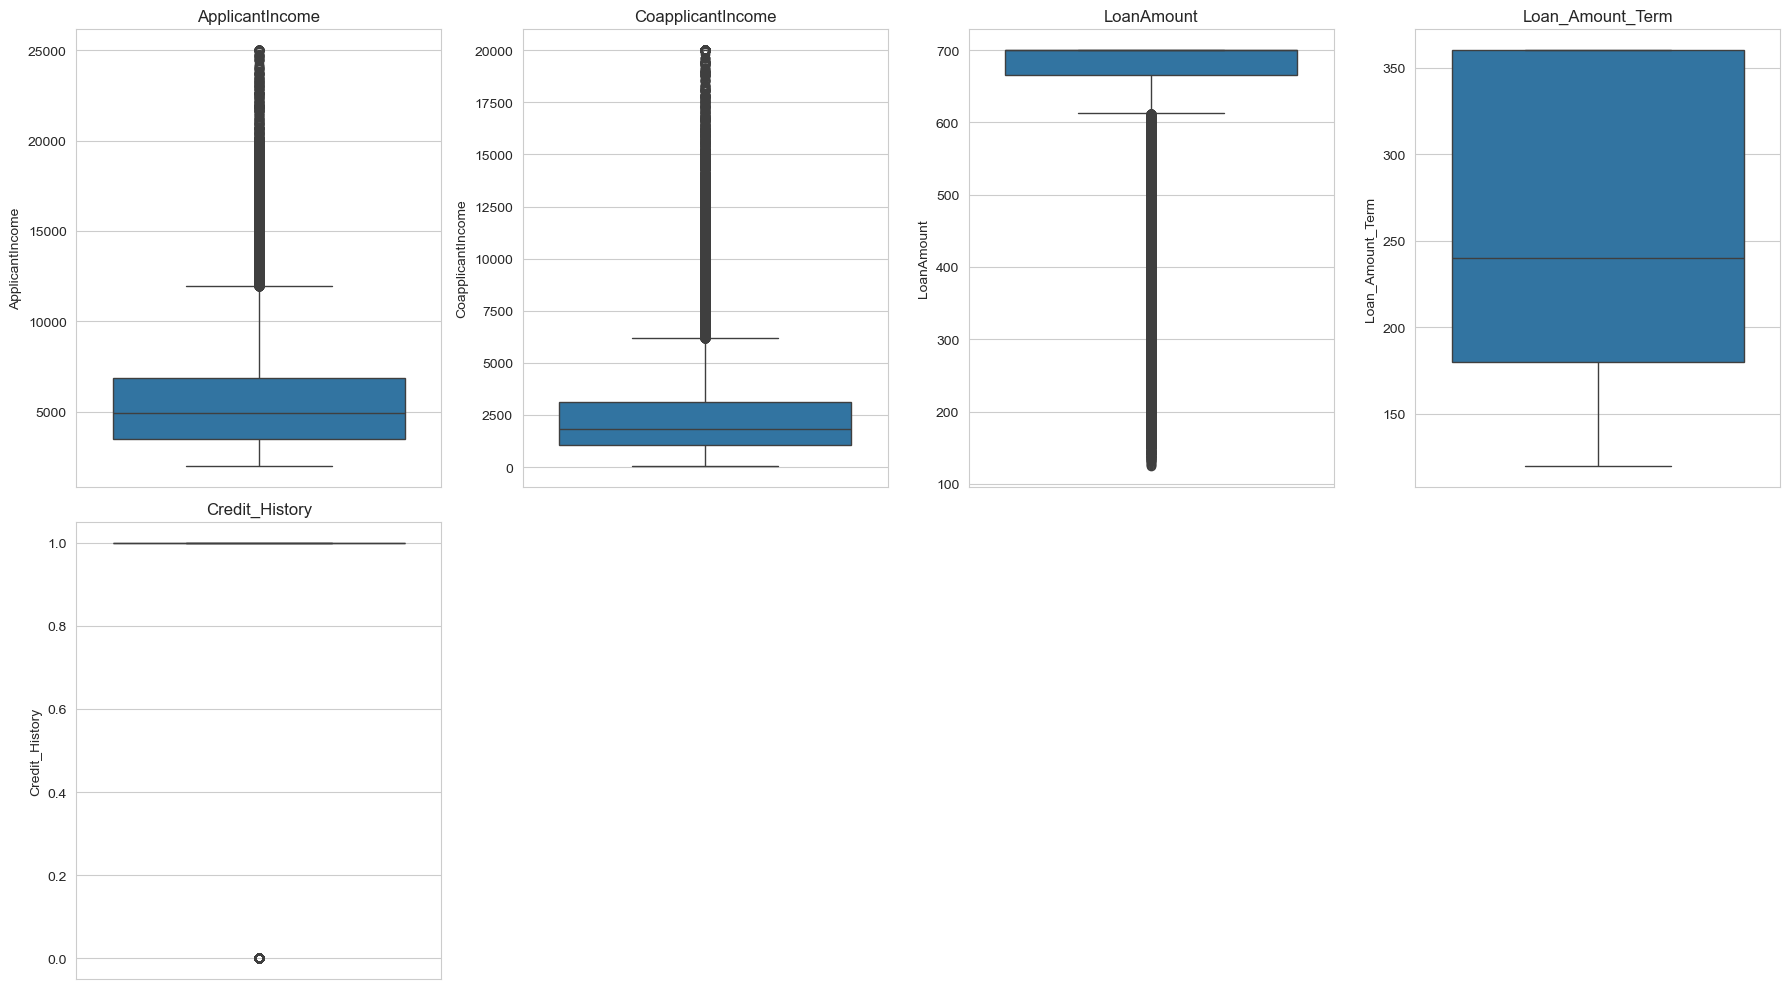

In [59]:
import math

num_cols_list = num_cols  # your numeric columns list

n = len(num_cols_list)

cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_list):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# hide extra plots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

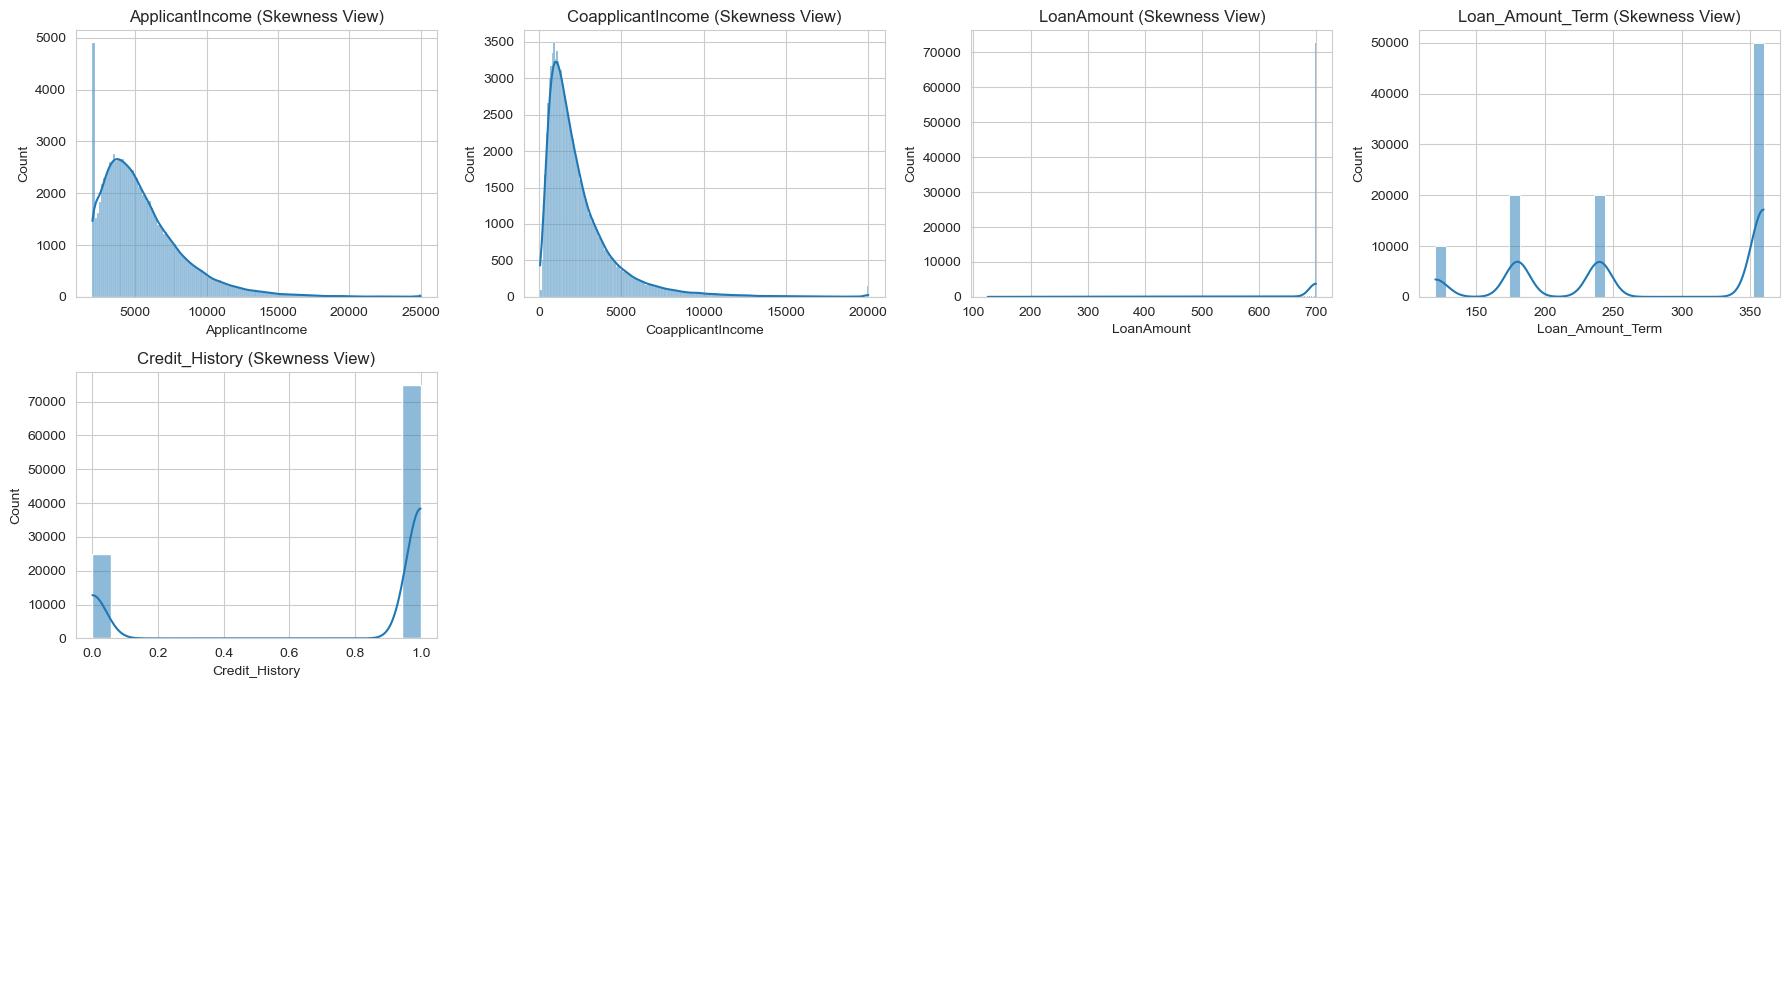

In [60]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col} (Skewness View)")

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [61]:
df[num_cols].skew()

ApplicantIncome      1.700634
CoapplicantIncome    2.848556
LoanAmount          -2.072280
Loan_Amount_Term    -0.369071
Credit_History      -1.155811
dtype: float64

In [62]:
df1=df.copy()

In [63]:
df1['ApplicantIncome'] = np.log1p(df1['ApplicantIncome'])
df1['CoapplicantIncome'] = np.log1p(df1['CoapplicantIncome'])
df1['LoanAmount'] = np.log1p(df1['LoanAmount'])

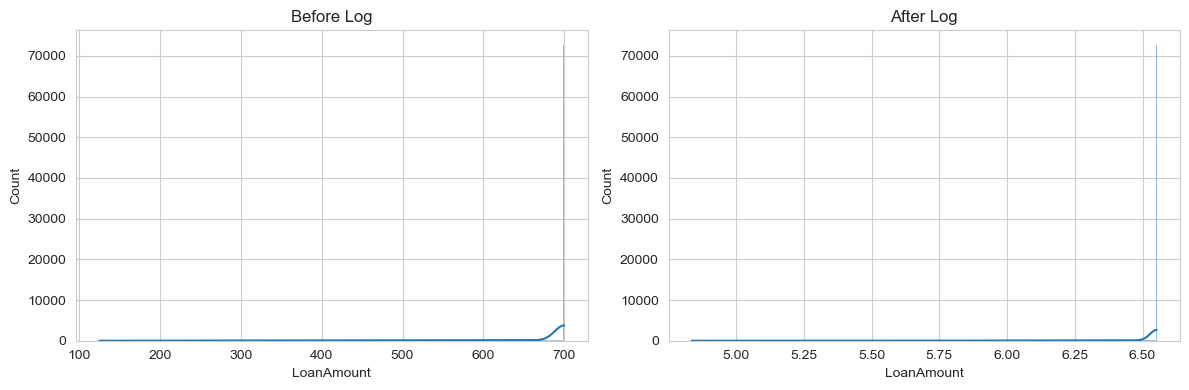

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['LoanAmount'], kde=True, ax=ax[0])
ax[0].set_title("Before Log")

sns.histplot(np.log1p(df['LoanAmount']), kde=True, ax=ax[1])
ax[1].set_title("After Log")

plt.tight_layout()
plt.show()

- Skewness close to 0 → Good
- Between -1 and 1 → Usually acceptable
- Greater than 1 or less than -1 → Highly skewed

## Log Transformation Analysis

- The `LoanAmount` feature was evaluated for log transformation.
- The transformed distribution showed no significant improvement over the original.
- Skewness increased after transformation, indicating no benefit.
- Therefore, the original `LoanAmount` values were retained.

In [67]:
df1[num_cols].skew()

ApplicantIncome      0.185329
CoapplicantIncome   -0.000598
LoanAmount          -2.625797
Loan_Amount_Term    -0.369071
Credit_History      -1.155811
dtype: float64

In [68]:
for col in cat_cols:
    print(col, "::::", df1[col].unique())

Gender :::: ['Male' 'Female']
Married :::: ['No' 'Yes']
Dependents :::: ['0' '1' '2' '3+']
Education :::: ['Not Graduate' 'Graduate']
Self_Employed :::: ['No' 'Yes']
Property_Area :::: ['Semiurban' 'Urban' 'Rural']
Loan_Status :::: ['Y' 'N']


In [71]:
df2=df.copy()

In [72]:
df2[num_cols].skew()

ApplicantIncome      1.700634
CoapplicantIncome    2.848556
LoanAmount          -2.072280
Loan_Amount_Term    -0.369071
Credit_History      -1.155811
dtype: float64

In [73]:
df2['ApplicantIncome'] = np.log1p(df2['ApplicantIncome'])
df2['CoapplicantIncome'] = np.log1p(df2['CoapplicantIncome'])

In [74]:
df2[num_cols].skew()

ApplicantIncome      0.185329
CoapplicantIncome   -0.000598
LoanAmount          -2.072280
Loan_Amount_Term    -0.369071
Credit_History      -1.155811
dtype: float64

In [75]:
df1['Dependents'] = df1['Dependents'].replace('3+', 3).astype(int)
df2['Dependents'] = df2['Dependents'].replace('3+', 3).astype(int)

In [76]:
print(df1['Dependents'].unique())
print(df2['Dependents'].unique())

[0 1 2 3]
[0 1 2 3]


## Note

Two datasets were created:
- **df1:** Log-transformed `LoanAmount`
- **df2:** Original `LoanAmount`

Both will be evaluated during model training, and the better-performing dataset will be used for the final model.

# Exploratory Data Analysis (EDA)

## Objective

The objective of this analysis is to understand the factors that influence loan approval. The analysis explores the relationship between applicant characteristics and the target variable (`Loan_Status`) to identify important predictors before data cleaning and feature engineering.

## Correlation Analysis

Correlation analysis is used to measure the relationship between numerical features. It helps identify strongly related variables and detect multicollinearity before model building.

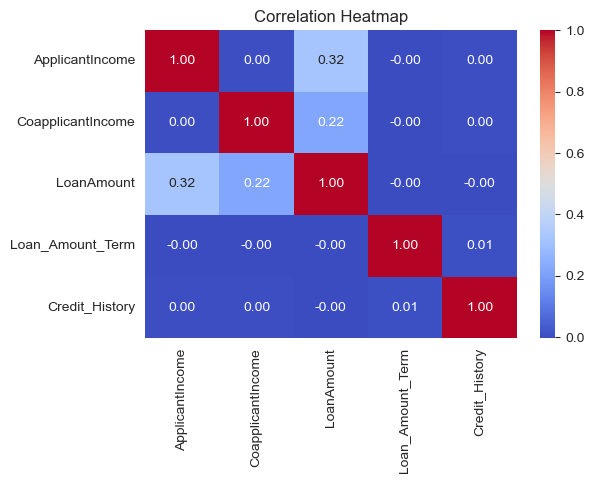

In [94]:
plt.figure(figsize=(6,4))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# Business Understanding

## Objective

The purpose of this analysis is to understand how applicant characteristics influence loan approval.  
Instead of analyzing individual feature distributions, this section focuses on answering key business questions using approval rates.

### Business Questions

- Does education influence loan approval?
- Does marital status influence loan approval?
- Does the number of dependents affect approval?
- Does loan repayment term influence approval?
- Does property area influence approval?
- Which applicant groups have higher approval rates?

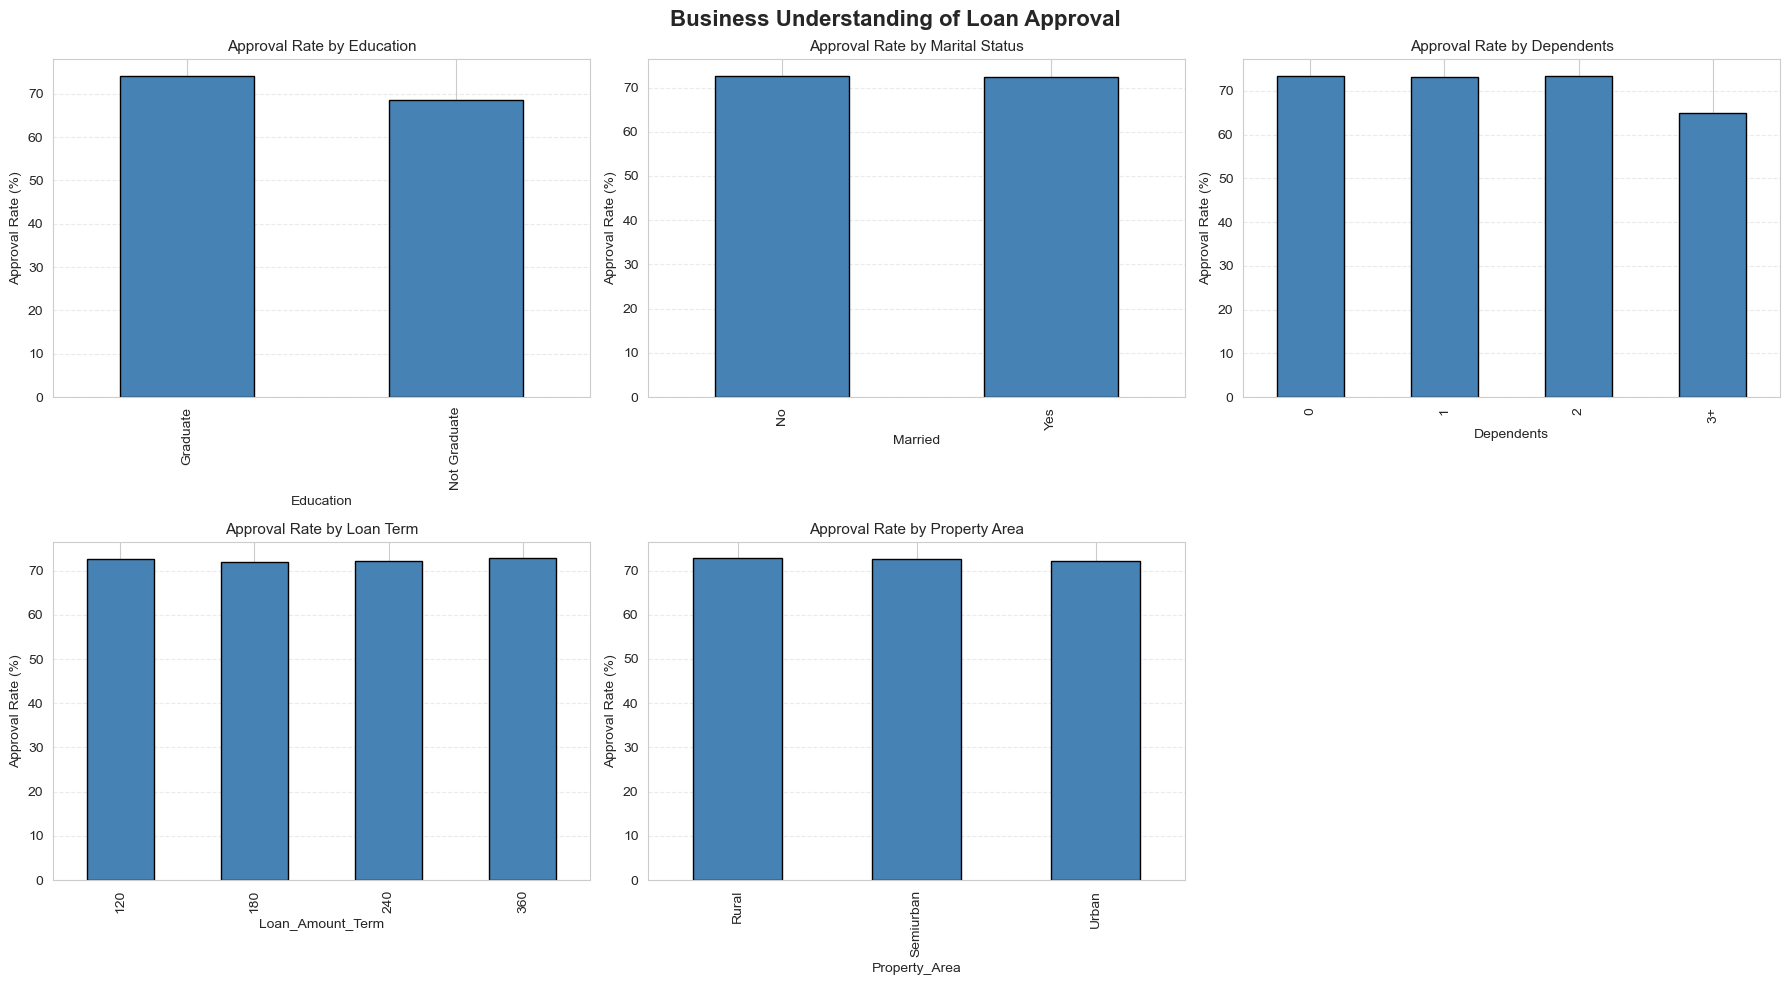

In [97]:
# Business features
business_cols = [
    'Education',
    'Married',
    'Dependents',
    'Loan_Amount_Term',
    'Property_Area'
]

titles = [
    'Approval Rate by Education',
    'Approval Rate by Marital Status',
    'Approval Rate by Dependents',
    'Approval Rate by Loan Term',
    'Approval Rate by Property Area'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(business_cols):

    approval_rate = pd.crosstab(
        df[col],
        df['Loan_Status'],
        normalize='index'
    ) * 100

    approval_rate['Y'].plot(
        kind='bar',
        ax=axes[i],
        color='steelblue',
        edgecolor='black'
    )

    axes[i].set_title(titles[i], fontsize=11)
    axes[i].set_ylabel('Approval Rate (%)')
    axes[i].set_xlabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

# Hide last empty subplot
axes[-1].axis('off')

plt.suptitle("Business Understanding of Loan Approval", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

## Business Insights

- Graduates have a slightly higher loan approval rate than non-graduates.
- Marital status has little impact on loan approval, as approval rates are nearly equal.
- Applicants with 3+ dependents have a slightly lower approval rate than other groups.
- Loan approval rates are similar across different loan terms, indicating loan tenure is not a major factor.
- Property area shows minimal influence on loan approval, with similar approval rates across Rural, Semiurban, and Urban areas.
- Most applicant characteristics show only small differences in approval rates.

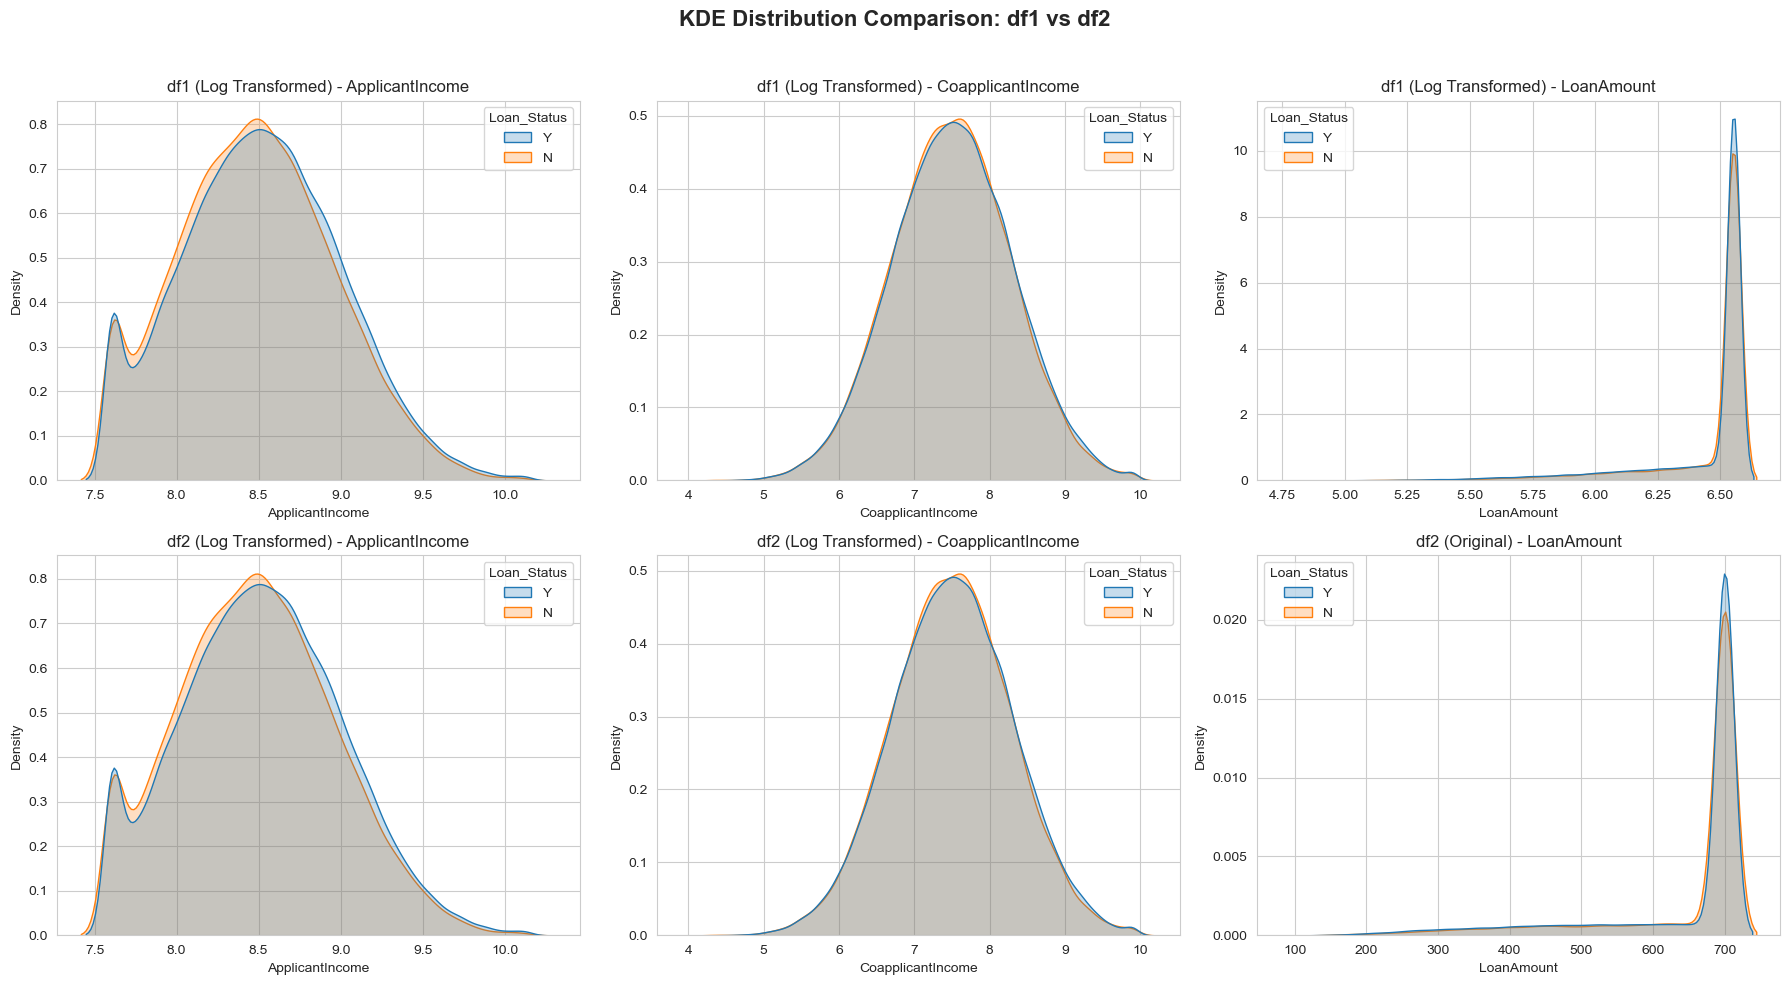

In [100]:
features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ==========================
# Row 1 : df1
# ==========================
for i, col in enumerate(features):
    sns.kdeplot(
        data=df1,
        x=col,
        hue='Loan_Status',
        fill=True,
        common_norm=False,
        ax=axes[0, i]
    )

    axes[0, i].set_title(f"df1 (Log Transformed) - {col}")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Density")

# ==========================
# Row 2 : df2
# ==========================
for i, col in enumerate(features):
    sns.kdeplot(
        data=df2,
        x=col,
        hue='Loan_Status',
        fill=True,
        common_norm=False,
        ax=axes[1, i]
    )

    if col == "LoanAmount":
        axes[1, i].set_title("df2 (Original) - LoanAmount")
    else:
        axes[1, i].set_title(f"df2 (Log Transformed) - {col}")

    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel("Density")

plt.suptitle(
    "KDE Distribution Comparison: df1 vs df2",
    fontsize=16,
    weight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## KDE Distribution Analysis - Key Observations

- Blue curves represent **approved loans (Y)**, while orange curves represent **rejected loans (N)**.
- In **df1**, all selected numerical features are log transformed.
- In **df2**, all selected numerical features are log transformed except **LoanAmount**, which remains in its original form.
- `LoanAmount` is **left-skewed (negative skewness)** in both datasets.
- Original `LoanAmount` skewness: **-2.07**
- Log-transformed `LoanAmount` skewness: **-2.63**
- Log transformation **increased the negative skewness** instead of reducing it.
- The distributions of approved and rejected loans still show considerable overlap, indicating that **LoanAmount alone is not a strong predictor** of loan approval.
- Both datasets (**df1** and **df2**) will be evaluated during model training to determine whether log transformation improves predictive performance.

# Business Insights

- Most loan applications are approved.
- Credit History is the strongest factor influencing loan approval.
- Applicant Income alone is not sufficient to determine loan approval.
- Loan Amount alone is not a strong predictor of loan approval.
- Property Area shows only a moderate influence on loan approval.
- Loan approval depends on a combination of applicant, financial, and credit-related features rather than a single feature.

# Feature Engineering

## Objective

Feature Engineering is the process of creating new features or transforming existing features to improve the predictive performance of machine learning models.

### Why is Feature Engineering Important?

- Creates more informative features from existing data.
- Helps models capture hidden patterns.
- Improves prediction accuracy.
- Makes business relationships easier to understand.

In [107]:
df3=df2.copy()
df4=df1.copy()

# Creating Working Copies

To preserve the original datasets, separate working copies are created before feature engineering.

- **df3:** Dataset with the original `LoanAmount`.
- **df4:** Dataset with the log-transformed `LoanAmount`.

This allows both datasets to undergo the same feature engineering and model training process for a fair performance comparison.

In [109]:
# ==========================
# Feature Engineering - df3
# ==========================

df3['TotalIncome'] = df3['ApplicantIncome'] + df3['CoapplicantIncome']
df3['LoanTermYears'] = (df3['Loan_Amount_Term'] / 12).astype(int)
df3['LoanIncomeRatio'] = df3['LoanAmount'] / df3['TotalIncome']
df3['EMI'] = df3['LoanAmount'] / df3['Loan_Amount_Term']

# ==========================
# Feature Engineering - df4
# ==========================

df4['TotalIncome'] = df4['ApplicantIncome'] + df4['CoapplicantIncome']
df4['LoanTermYears'] = (df4['Loan_Amount_Term'] / 12).astype(int)
df4['LoanIncomeRatio'] = df4['LoanAmount'] / df4['TotalIncome']
df4['EMI'] = df4['LoanAmount'] / df4['Loan_Amount_Term']



In [110]:
# Display newly created features
df3[['TotalIncome',
    'LoanTermYears',
    'LoanIncomeRatio',
    'EMI']].head()

,TotalIncome,LoanTermYears,LoanIncomeRatio,EMI
0,14.649789,20,16.928572,1.033333
1,18.040035,10,38.802585,5.833333
2,15.493011,30,19.879932,0.855556
3,15.083438,20,46.408518,2.916667
4,16.274840,30,21.136921,0.955556


In [115]:
# Display newly created features
df4[['TotalIncome',
    'LoanTermYears',
    'LoanIncomeRatio',
    'EMI']].head()

,TotalIncome,LoanTermYears,LoanIncomeRatio,EMI
0,14.649789,20,0.376623,0.022989
1,18.040035,10,0.363220,0.054604
2,15.493011,30,0.370060,0.015926
3,15.083438,20,0.434417,0.027302
4,16.274840,30,0.359054,0.016232


# Feature Selection

## Objective

Feature Selection is the process of identifying the most relevant features for model training while removing unnecessary or redundant variables.

### Why Feature Selection?

- Reduces model complexity.
- Removes irrelevant or redundant features.
- Improves model performance.
- Reduces overfitting.
- Makes the model easier to interpret.

Unlike Feature Engineering, which creates new variables, Feature Selection chooses the most useful features from the existing dataset.

In [119]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99999 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             99999 non-null  object 
 1   Married            99999 non-null  object 
 2   Dependents         99999 non-null  int32  
 3   Education          99999 non-null  object 
 4   Self_Employed      99999 non-null  object 
 5   ApplicantIncome    99999 non-null  float64
 6   CoapplicantIncome  99999 non-null  float64
 7   LoanAmount         99999 non-null  float64
 8   Loan_Amount_Term   99999 non-null  int64  
 9   Credit_History     99999 non-null  int64  
 10  Property_Area      99999 non-null  object 
 11  Loan_Status        99999 non-null  object 
 12  TotalIncome        99999 non-null  float64
 13  LoanTermYears      99999 non-null  int32  
 14  LoanIncomeRatio    99999 non-null  float64
 15  EMI                99999 non-null  float64
dtypes: float64(6), int32(2), in

In [121]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99999 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             99999 non-null  object 
 1   Married            99999 non-null  object 
 2   Dependents         99999 non-null  int32  
 3   Education          99999 non-null  object 
 4   Self_Employed      99999 non-null  object 
 5   ApplicantIncome    99999 non-null  float64
 6   CoapplicantIncome  99999 non-null  float64
 7   LoanAmount         99999 non-null  int64  
 8   Loan_Amount_Term   99999 non-null  int64  
 9   Credit_History     99999 non-null  int64  
 10  Property_Area      99999 non-null  object 
 11  Loan_Status        99999 non-null  object 
 12  TotalIncome        99999 non-null  float64
 13  LoanTermYears      99999 non-null  int32  
 14  LoanIncomeRatio    99999 non-null  float64
 15  EMI                99999 non-null  float64
dtypes: float64(5), int32(2), in

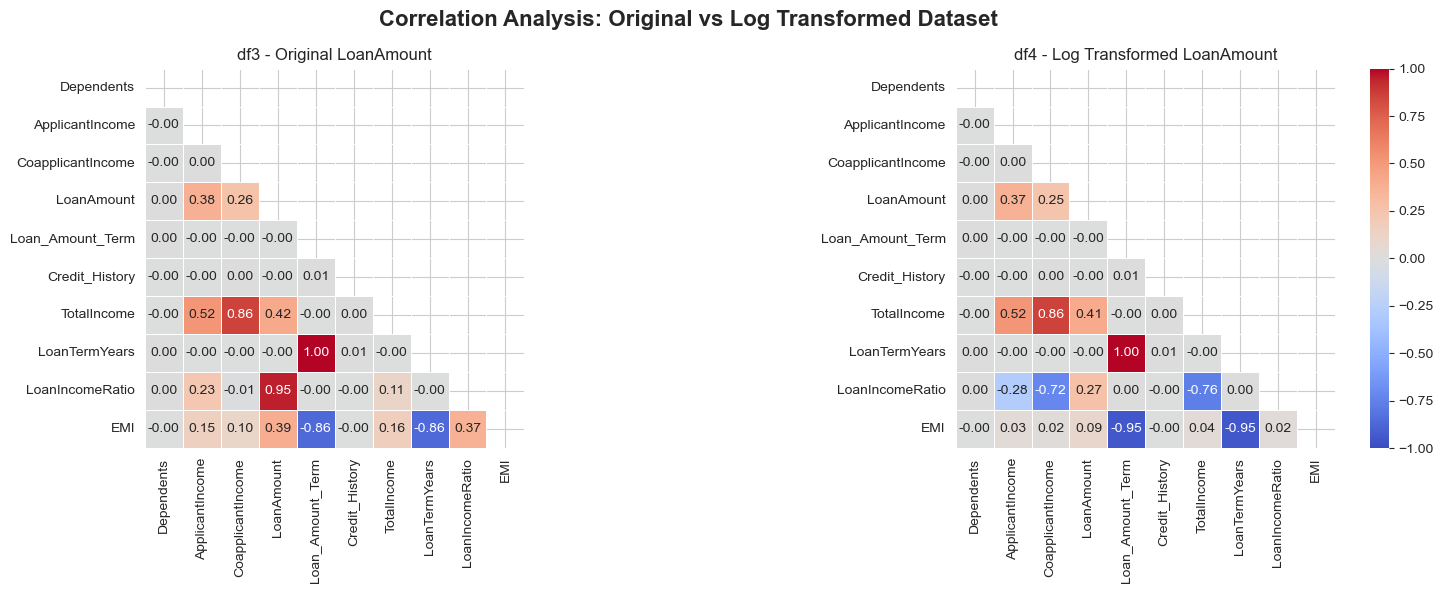

In [123]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mask for upper triangle
mask3 = np.triu(np.ones_like(df3.corr(numeric_only=True), dtype=bool))
mask4 = np.triu(np.ones_like(df4.corr(numeric_only=True), dtype=bool))

# -----------------------------
# df3 Heatmap (Original LoanAmount)
# -----------------------------
sns.heatmap(
    df3.corr(numeric_only=True),
    mask=mask3,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar=False,
    ax=axes[0]
)

axes[0].set_title("df3 - Original LoanAmount")

# -----------------------------
# df4 Heatmap (Log LoanAmount)
# -----------------------------
sns.heatmap(
    df4.corr(numeric_only=True),
    mask=mask4,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar=True,
    ax=axes[1]
)

axes[1].set_title("df4 - Log Transformed LoanAmount")

plt.suptitle("Correlation Analysis: Original vs Log Transformed Dataset",
             fontsize=16,
             fontweight="bold")

plt.tight_layout()
plt.show()

In [125]:
# Drop Loan_Amount_Term from df3
df3 = df3.drop(columns=['Loan_Amount_Term'])

# Drop Loan_Amount_Term from df4
df4 = df4.drop(columns=['Loan_Amount_Term'])

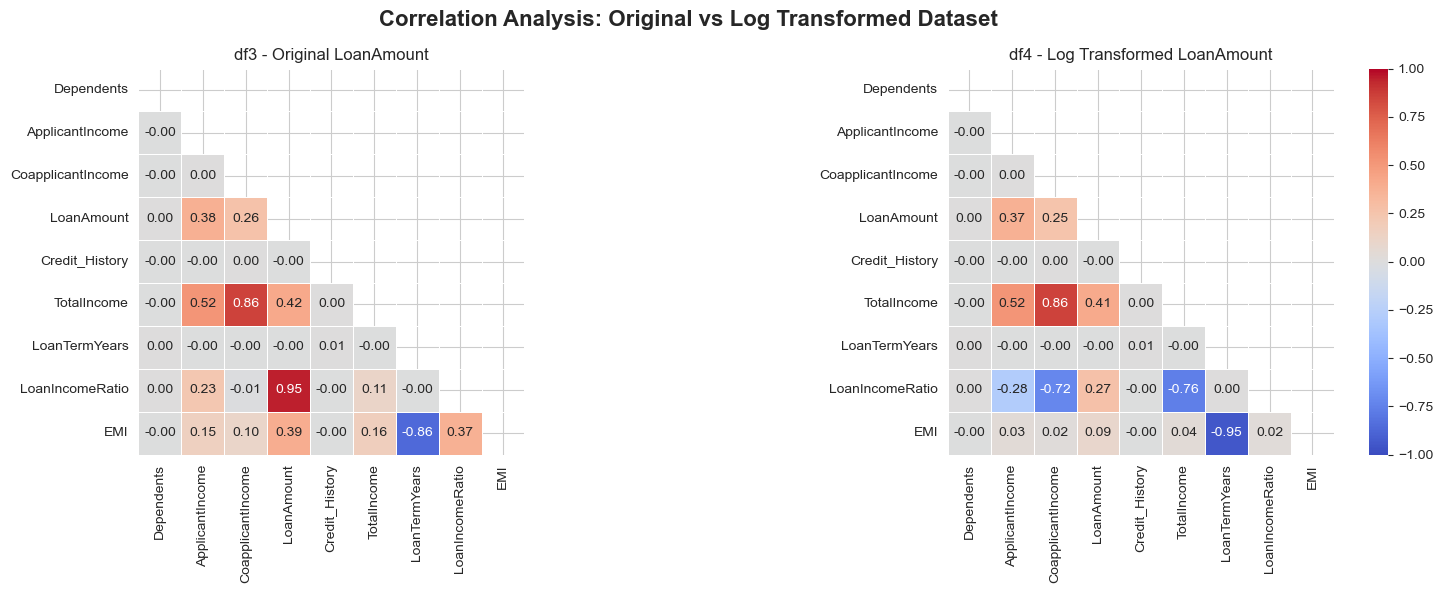

In [127]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mask for upper triangle
mask3 = np.triu(np.ones_like(df3.corr(numeric_only=True), dtype=bool))
mask4 = np.triu(np.ones_like(df4.corr(numeric_only=True), dtype=bool))

# -----------------------------
# df3 Heatmap (Original LoanAmount)
# -----------------------------
sns.heatmap(
    df3.corr(numeric_only=True),
    mask=mask3,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar=False,
    ax=axes[0]
)

axes[0].set_title("df3 - Original LoanAmount")

# -----------------------------
# df4 Heatmap (Log LoanAmount)
# -----------------------------
sns.heatmap(
    df4.corr(numeric_only=True),
    mask=mask4,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar=True,
    ax=axes[1]
)

axes[1].set_title("df4 - Log Transformed LoanAmount")

plt.suptitle("Correlation Analysis: Original vs Log Transformed Dataset",
             fontsize=16,
             fontweight="bold")

plt.tight_layout()
plt.show()

# Correlation Analysis - Observations

### Key Findings

- `Loan_Amount_Term` and `LoanTermYears` have a perfect positive correlation (1.00), indicating they contain identical information in different units. Therefore, only one of them will be retained for model training.
- `LoanAmount` and `LoanIncomeRatio` show a strong positive correlation because the ratio is derived using the loan amount. This relationship is expected from a business perspective.
- `CoapplicantIncome` and `TotalIncome` are highly correlated since `TotalIncome` is calculated using applicant and co-applicant incomes.
- The correlation patterns in the original `LoanAmount` dataset are more intuitive and easier to interpret from a business standpoint.
- Final feature selection will be based on model performance and feature importance rather than correlation alone.

# Variance Inflation Factor (VIF)

## What is VIF?

Variance Inflation Factor (VIF) is a statistical measure used to detect **multicollinearity** among numerical features.

Multicollinearity occurs when one feature can be highly explained by one or more other features.

---

## Why is VIF Used?

- Detects highly correlated numerical features.
- Helps reduce redundant information.
- Improves model stability and interpretability.
- Particularly important for Linear Regression and Logistic Regression models.

---

## VIF Interpretation

| VIF Value | Interpretation |
|-----------|----------------|
| < 5 | Low multicollinearity (Good) |
| 5 – 10 | Moderate multicollinearity |
| > 10 | High multicollinearity (Consider removing the feature) |

In [132]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Function to calculate VIF
def calculate_vif(df):

    # Select only numerical columns
    X = df.select_dtypes(include='number')

    vif = pd.DataFrame()
    vif["Feature"] = X.columns
    vif["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif.sort_values(by="VIF", ascending=False).reset_index(drop=True)


# -----------------------------
# VIF for df3
# -----------------------------
print("=" * 60)
print("VIF - df3 (Original LoanAmount)")
print("=" * 60)

vif_df3 = calculate_vif(df3)
display(vif_df3)

# -----------------------------
# VIF for df4
# -----------------------------
print("=" * 60)
print("VIF - df4 (Log Transformed LoanAmount)")
print("=" * 60)

vif_df4 = calculate_vif(df4)
display(vif_df4)

VIF - df3 (Original LoanAmount)


C:\Users\karth\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,ApplicantIncome,inf
1,CoapplicantIncome,inf
2,TotalIncome,inf
3,LoanIncomeRatio,516.136862
4,LoanAmount,487.289328
5,LoanTermYears,83.007385
6,EMI,52.819965
7,Credit_History,4.002484
8,Dependents,1.998041


VIF - df4 (Log Transformed LoanAmount)


C:\Users\karth\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,ApplicantIncome,inf
1,CoapplicantIncome,inf
2,TotalIncome,inf
3,LoanAmount,3019.518119
4,LoanIncomeRatio,939.900827
5,LoanTermYears,107.243285
6,EMI,68.180047
7,Credit_History,4.003273
8,Dependents,1.997997


## Removing Redundant Features

During VIF analysis, `ApplicantIncome`, `CoapplicantIncome`, and `TotalIncome` showed perfect multicollinearity because:

- `TotalIncome = ApplicantIncome + CoapplicantIncome`

Since `TotalIncome` captures the combined earning capacity of the applicant and co-applicant, the individual income columns become redundant.

To reduce multicollinearity and retain a more meaningful business feature, `ApplicantIncome` and `CoapplicantIncome` were removed while keeping `TotalIncome`.

This simplifies the feature set and helps improve model stability, especially for linear models.

In [135]:
# ---------------------------------------------------
# Remove redundant features after VIF analysis
# ---------------------------------------------------

# df3: Original LoanAmount dataset
df3_fs = df3.drop(columns=['ApplicantIncome', 'CoapplicantIncome'])

# df4: Log-transformed LoanAmount dataset
df4_fs = df4.drop(columns=['ApplicantIncome', 'CoapplicantIncome'])

print("df3_fs Shape:", df3_fs.shape)
print("df4_fs Shape:", df4_fs.shape)

display(df3_fs.head())
display(df4_fs.head())

df3_fs Shape: (99999, 13)
df4_fs Shape: (99999, 13)


,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanTermYears,LoanIncomeRatio,EMI
0,Male,No,0,Not Graduate,No,248,1,Semiurban,Y,14.649789,20,16.928572,1.033333
1,Female,Yes,1,Graduate,No,700,0,Urban,N,18.040035,10,38.802585,5.833333
2,Male,Yes,2,Graduate,No,308,1,Urban,Y,15.493011,30,19.879932,0.855556
3,Male,No,2,Graduate,No,700,1,Urban,Y,15.083438,20,46.408518,2.916667
4,Male,Yes,2,Graduate,No,344,1,Rural,Y,16.274840,30,21.136921,0.955556


,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanTermYears,LoanIncomeRatio,EMI
0,Male,No,0,Not Graduate,No,5.517453,1,Semiurban,Y,14.649789,20,0.376623,0.022989
1,Female,Yes,1,Graduate,No,6.552508,0,Urban,N,18.040035,10,0.363220,0.054604
2,Male,Yes,2,Graduate,No,5.733341,1,Urban,Y,15.493011,30,0.370060,0.015926
3,Male,No,2,Graduate,No,6.552508,1,Urban,Y,15.083438,20,0.434417,0.027302
4,Male,Yes,2,Graduate,No,5.843544,1,Rural,Y,16.274840,30,0.359054,0.016232


In [137]:
vif_df3 = calculate_vif(df3_fs)
display(vif_df3)

vif_df4 = calculate_vif(df4_fs)
display(vif_df4)

,Feature,VIF
0,LoanIncomeRatio,398.403399
1,LoanAmount,383.329384
2,TotalIncome,124.867692
3,LoanTermYears,83.005952
4,EMI,52.818989
5,Credit_History,4.002481
6,Dependents,1.998041


,Feature,VIF
0,LoanAmount,3018.991107
1,TotalIncome,992.722398
2,LoanIncomeRatio,899.372608
3,LoanTermYears,107.242252
4,EMI,68.179669
5,Credit_History,4.003248
6,Dependents,1.997997


## Variance Inflation Factor (VIF) Analysis

VIF analysis was performed after feature engineering to identify multicollinearity among numerical features.

Initially, `ApplicantIncome`, `CoapplicantIncome`, and `TotalIncome` exhibited perfect multicollinearity because:

- `TotalIncome = ApplicantIncome + CoapplicantIncome`

To eliminate redundant information, `ApplicantIncome` and `CoapplicantIncome` were removed while retaining `TotalIncome`, which better represents the overall earning capacity of the applicant's household.

After removing the redundant features, VIF values were recalculated. Some engineered features, such as `LoanIncomeRatio` and `EMI`, still showed high VIF values because they are mathematically derived from existing variables (`LoanAmount`, `TotalIncome`, and `LoanTermYears`).

This level of multicollinearity is expected after feature engineering and is generally less problematic for tree-based classification models such as Decision Tree, Random Forest, XGBoost, and CatBoost.

For this project, the engineered features are retained because they provide meaningful business information. Their usefulness will be evaluated during model training and feature importance analysis.

# Feature Importance

## What is Feature Importance?

Feature Importance is a model-based technique used to measure how much each feature contributes to predicting the target variable.

It helps identify the most influential variables while reducing the impact of less useful features.

---

## Why is Feature Importance Used?

- Identifies the most predictive features.
- Helps remove irrelevant or low-impact variables.
- Improves model interpretability.
- Can reduce overfitting by eliminating unnecessary features.
- Supports selecting the final feature set for model training.

---

## Final Feature Selection

After evaluating feature importance, the most informative features are retained for training the final classification models, while features with negligible importance may be removed.

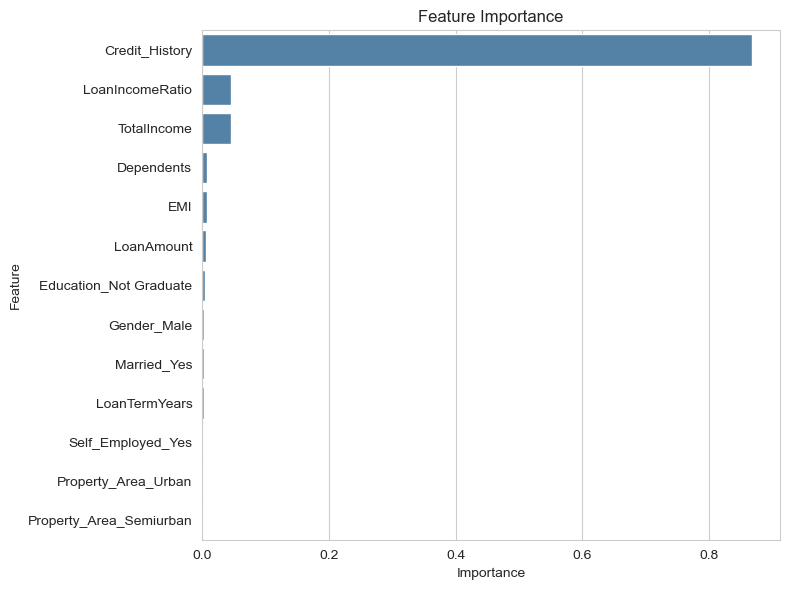

,Feature,Importance
2,Credit_History,0.868053
5,LoanIncomeRatio,0.046131
3,TotalIncome,0.045686
0,Dependents,0.008057
6,EMI,0.007162
1,LoanAmount,0.005611
9,Education_Not Graduate,0.005181
7,Gender_Male,0.002737
8,Married_Yes,0.002656
4,LoanTermYears,0.002616


In [142]:
from sklearn.ensemble import RandomForestClassifier

# Encode target
df_fs = df3_fs.copy()   # or df4_fs

df_fs['Loan_Status'] = df_fs['Loan_Status'].map({'N': 0, 'Y': 1})

# One-hot encode categorical features
df_encoded = pd.get_dummies(df_fs, drop_first=True)

# Split features and target
X = df_encoded.drop('Loan_Status', axis=1)
y = df_encoded['Loan_Status']

# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(data=importance, x='Importance', y='Feature', color='steelblue')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

# Display importance values
display(importance)

In [143]:
#this is important feature columns for build if main model fails
'''selected_features = [
    'Credit_History',
    'TotalIncome',
    'LoanIncomeRatio',
    'EMI',
    'Loan_Status'
]

df3_final = df3_fs[selected_features]
df4_final = df4_fs[selected_features]'''

"selected_features = [\n    'Credit_History',\n    'TotalIncome',\n    'LoanIncomeRatio',\n    'EMI',\n    'Loan_Status'\n]\n\ndf3_final = df3_fs[selected_features]\ndf4_final = df4_fs[selected_features]"

In [144]:
'''## Feature Importance Analysis

A Random Forest classifier was used to estimate the importance of each feature in predicting loan approval.

### Observations

- **Credit_History** is the most influential feature, contributing approximately **86%** of the total importance.
- **TotalIncome** and **LoanIncomeRatio** provide moderate predictive power and represent the applicant's repayment capacity.
- **EMI** has a relatively small contribution but still captures repayment burden.
- **LoanAmount**, **Education**, **Gender**, **Marital Status**, **Property Area**, and **Dependents** individually contribute less to the prediction.
- Although several features have low individual importance, they may still improve overall model performance when combined with other features.
- Therefore, the complete feature set will be retained initially, and model performance will be compared with a reduced feature set before selecting the final features.'''

"## Feature Importance Analysis\n\nA Random Forest classifier was used to estimate the importance of each feature in predicting loan approval.\n\n### Observations\n\n- **Credit_History** is the most influential feature, contributing approximately **86%** of the total importance.\n- **TotalIncome** and **LoanIncomeRatio** provide moderate predictive power and represent the applicant's repayment capacity.\n- **EMI** has a relatively small contribution but still captures repayment burden.\n- **LoanAmount**, **Education**, **Gender**, **Marital Status**, **Property Area**, and **Dependents** individually contribute less to the prediction.\n- Although several features have low individual importance, they may still improve overall model performance when combined with other features.\n- Therefore, the complete feature set will be retained initially, and model performance will be compared with a reduced feature set before selecting the final features."

## Final Feature Selection Strategy

Feature importance analysis showed that `Credit_History` is the most influential feature, followed by `TotalIncome` and `LoanIncomeRatio`.

Instead of removing low-importance features immediately, all remaining features are retained for the initial model training. This ensures that potentially useful information is not discarded prematurely.

A second reduced feature set containing only the most important features will also be evaluated. The performance of both datasets will be compared, and the feature set that produces the best classification results will be selected as the final model input.

This approach balances business interpretability with predictive performance and follows a practical machine learning workflow.

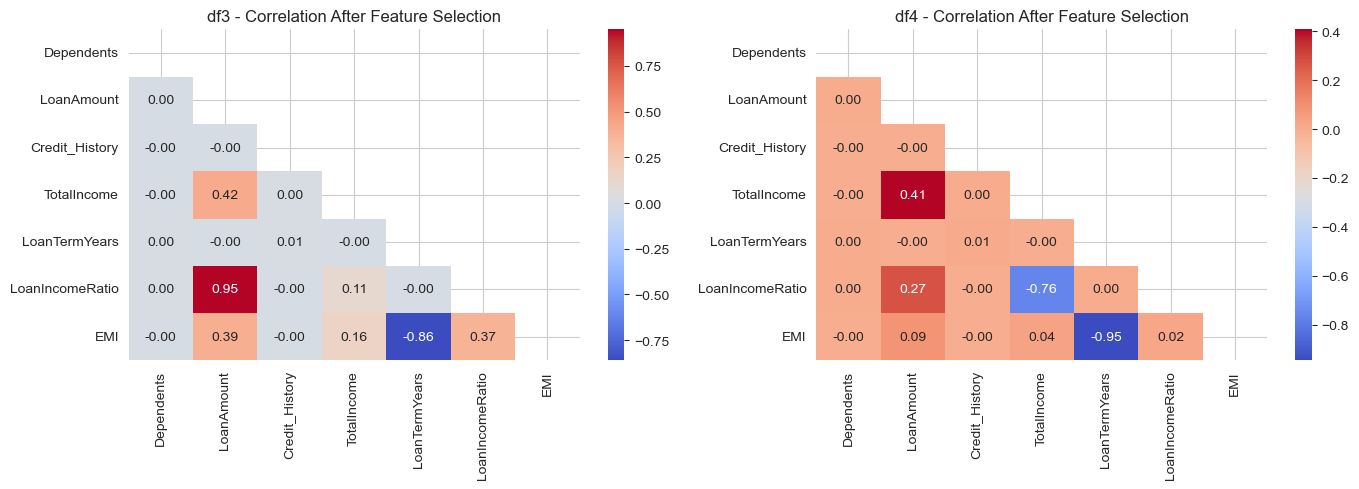

In [146]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Mask for upper triangle
mask3 = np.triu(np.ones(df3_fs.corr(numeric_only=True).shape, dtype=bool))
mask4 = np.triu(np.ones(df4_fs.corr(numeric_only=True).shape, dtype=bool))

# df3
sns.heatmap(df3_fs.corr(numeric_only=True),
            mask=mask3,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            ax=ax[0])

ax[0].set_title("df3 - Correlation After Feature Selection")

# df4
sns.heatmap(df4_fs.corr(numeric_only=True),
            mask=mask4,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            ax=ax[1])

ax[1].set_title("df4 - Correlation After Feature Selection")

plt.tight_layout()
plt.show()

# Encoding

## What is Encoding?

Encoding is the process of converting categorical variables into numerical values so that machine learning algorithms can process them.

Most machine learning models cannot work directly with text-based categorical data.

---

## Why is Encoding Used?

- Converts categorical features into numerical format.
- Makes data compatible with machine learning algorithms.
- Preserves useful information contained in categorical variables.
- Improves model training and prediction performance.

---

## Encoding Method

One-Hot Encoding is used for nominal categorical variables.

It creates separate binary columns for each category while avoiding any ordinal relationship between categories.

In [153]:
# Create copies
df3_encoded = df3_fs.copy()
df4_encoded = df4_fs.copy()

# ---------------------------------
# Label Encoding (Binary Features)
# ---------------------------------
binary_map = {
    'Gender': {'Male': 1, 'Female': 0},
    'Married': {'Yes': 1, 'No': 0},
    'Education': {'Graduate': 1, 'Not Graduate': 0},
    'Self_Employed': {'Yes': 1, 'No': 0},   # <-- Added
    'Loan_Status': {'Y': 1, 'N': 0}
}

for col, mapping in binary_map.items():
    df3_encoded[col] = df3_encoded[col].map(mapping)
    df4_encoded[col] = df4_encoded[col].map(mapping)

# ---------------------------------
# One-Hot Encoding (Nominal Feature)
# ---------------------------------
df3_encoded = pd.get_dummies(
    df3_encoded,
    columns=['Property_Area'],
    drop_first=True,
    dtype=int
)

df4_encoded = pd.get_dummies(
    df4_encoded,
    columns=['Property_Area'],
    drop_first=True,
    dtype=int
)

# Check for remaining object columns
print("Object columns in df3:")
print(df3_encoded.select_dtypes(include='object').columns)

print("\nObject columns in df4:")
print(df4_encoded.select_dtypes(include='object').columns)

# Display encoded datasets
print("\ndf3_encoded")
display(df3_encoded.head())

print("\ndf4_encoded")
display(df4_encoded.head())

Object columns in df3:
Index([], dtype='object')

Object columns in df4:
Index([], dtype='object')

df3_encoded


,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Credit_History,Loan_Status,TotalIncome,LoanTermYears,LoanIncomeRatio,EMI,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,248,1,1,14.649789,20,16.928572,1.033333,1,0
1,0,1,1,1,0,700,0,0,18.040035,10,38.802585,5.833333,0,1
2,1,1,2,1,0,308,1,1,15.493011,30,19.879932,0.855556,0,1
3,1,0,2,1,0,700,1,1,15.083438,20,46.408518,2.916667,0,1
4,1,1,2,1,0,344,1,1,16.274840,30,21.136921,0.955556,0,0



df4_encoded


,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Credit_History,Loan_Status,TotalIncome,LoanTermYears,LoanIncomeRatio,EMI,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5.517453,1,1,14.649789,20,0.376623,0.022989,1,0
1,0,1,1,1,0,6.552508,0,0,18.040035,10,0.363220,0.054604,0,1
2,1,1,2,1,0,5.733341,1,1,15.493011,30,0.370060,0.015926,0,1
3,1,0,2,1,0,6.552508,1,1,15.083438,20,0.434417,0.027302,0,1
4,1,1,2,1,0,5.843544,1,1,16.274840,30,0.359054,0.016232,0,0


# Encoding

## Objective

Machine learning algorithms require numerical input. Therefore, categorical variables were converted into numerical values before model training.

### Encoding Strategy

**Label Encoding** was applied to binary categorical variables:

- Gender
- Married
- Education
- Loan_Status (Target)

**One-Hot Encoding** was applied to:

- Property_Area

This approach preserves the information contained in categorical variables while avoiding the introduction of an artificial order for nominal features such as `Property_Area`.

# Train-Test Split

## What is Train-Test Split?

Train-Test Split is the process of dividing the dataset into two subsets:

- **Training Set:** Used to train the machine learning model.
- **Testing Set:** Used to evaluate the model on unseen data.

This helps measure how well the model generalizes to new data and prevents overestimating its performance.

---

## Why is Train-Test Split Used?

- Prevents overfitting.
- Evaluates model performance on unseen data.
- Provides a fair comparison between different classification models.
- Simulates real-world prediction on new loan applications.

---

## Split Ratio

The dataset is divided using an **80:20 ratio**, where:

- **80%** of the data is used for training.
- **20%** of the data is used for testing.

The target variable is stratified to preserve the original class distribution in both training and testing sets.

In [160]:
from sklearn.model_selection import train_test_split

# -------------------------
# df3 (Original LoanAmount)
# -------------------------
X3 = df3_encoded.drop('Loan_Status', axis=1)
y3 = df3_encoded['Loan_Status']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

# -------------------------
# df4 (Log LoanAmount)
# -------------------------
X4 = df4_encoded.drop('Loan_Status', axis=1)
y4 = df4_encoded['Loan_Status']

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4,
    y4,
    test_size=0.2,
    random_state=42,
    stratify=y4
)

print("df3 Training Shape :", X3_train.shape)
print("df3 Testing Shape  :", X3_test.shape)

print("\ndf4 Training Shape :", X4_train.shape)
print("df4 Testing Shape  :", X4_test.shape)

df3 Training Shape : (79999, 13)
df3 Testing Shape  : (20000, 13)

df4 Training Shape : (79999, 13)
df4 Testing Shape  : (20000, 13)


## Feature Scaling

Feature Scaling standardizes numerical features so that they have a similar range. This prevents features with larger values from dominating the learning process.

Two scaling techniques are evaluated:

- **StandardScaler:** Centers data around a mean of 0 with a standard deviation of 1.
- **MinMaxScaler:** Scales data to a range between 0 and 1.

The performance of both scaling methods will be compared for scale-sensitive classification models such as Logistic Regression, KNN, and SVM.

In [165]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ===============================
# Standard Scaling
# ===============================

std_scaler_df3 = StandardScaler()
X3_train_std = std_scaler_df3.fit_transform(X3_train)
X3_test_std = std_scaler_df3.transform(X3_test)

std_scaler_df4 = StandardScaler()
X4_train_std = std_scaler_df4.fit_transform(X4_train)
X4_test_std = std_scaler_df4.transform(X4_test)

# ===============================
# Min-Max Scaling
# ===============================

mm_scaler_df3 = MinMaxScaler()
X3_train_mm = mm_scaler_df3.fit_transform(X3_train)
X3_test_mm = mm_scaler_df3.transform(X3_test)

mm_scaler_df4 = MinMaxScaler()
X4_train_mm = mm_scaler_df4.fit_transform(X4_train)
X4_test_mm = mm_scaler_df4.transform(X4_test)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


In [170]:
# Standard scaled dataframe

X4_train_std_df = pd.DataFrame(
    X4_train_std,
    columns=X4_train.columns
)

X4_train_std_df.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Credit_History,TotalIncome,LoanTermYears,LoanIncomeRatio,EMI,Property_Area_Semiurban,Property_Area_Urban
0,1.001038,0.817547,0.996234,0.653452,-0.420931,-0.702753,-1.733423,-0.999234,0.937330,0.556831,-0.829976,-0.737015,-0.810691
1,-0.998963,-1.223171,-0.998079,-1.530335,2.375686,-2.350315,-1.733423,-1.373018,0.937330,-0.214334,-0.928142,-0.737015,1.233515
2,1.001038,-1.223171,1.993390,0.653452,-0.420931,0.451916,0.576893,0.603231,0.937330,-0.356793,-0.761177,1.356825,-0.810691
3,-0.998963,-1.223171,-0.998079,-1.530335,-0.420931,-1.101434,-1.733423,-0.396829,0.937330,-0.382375,-0.853730,-0.737015,-0.810691
4,-0.998963,0.817547,-0.000922,0.653452,-0.420931,-1.058931,0.576893,0.212044,-0.399488,-0.968437,-0.095550,1.356825,-0.810691


In [172]:
# MinMax scaled dataframe

X4_train_mm_df = pd.DataFrame(
    X4_train_mm,
    columns=X4_train.columns
)

X4_train_mm_df.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Credit_History,TotalIncome,LoanTermYears,LoanIncomeRatio,EMI,Property_Area_Semiurban,Property_Area_Urban
0,1.0,1.0,0.666667,1.0,0.0,0.835966,0.0,0.359436,1.0,0.450593,0.096801,0.0,0.0
1,0.0,0.0,0.000000,0.0,1.0,0.601911,0.0,0.314293,1.0,0.362390,0.069698,0.0,1.0
2,1.0,0.0,1.000000,1.0,0.0,1.000000,1.0,0.552973,1.0,0.346096,0.115795,1.0,0.0
3,0.0,0.0,0.000000,0.0,0.0,0.779329,0.0,0.432191,1.0,0.343170,0.090242,0.0,0.0
4,0.0,1.0,0.333333,1.0,0.0,0.785367,1.0,0.505727,0.5,0.276138,0.299566,1.0,0.0


In [174]:
print(type(std_scaler_df4))

<class 'sklearn.preprocessing._data.StandardScaler'>


## Feature Scaling

Feature Scaling transforms numerical features to a similar scale, preventing features with larger values from dominating the learning process.

Two scaling techniques were applied:

- **StandardScaler:** Standardizes features with mean = 0 and standard deviation = 1.
- **MinMaxScaler:** Scales features to the range [0, 1].

Both scaling methods will be evaluated with scale-sensitive classification algorithms.

## Baseline Model Training

Baseline models provide an initial benchmark for classification performance using default parameters. Multiple algorithms are trained and evaluated before applying class balancing or hyperparameter tuning.

The following classification algorithms are used:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest
- Naive Bayes
- XGBoost

The performance of each model is evaluated using Accuracy, Precision, Recall, and F1-Score.

In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train and Evaluate
for name, model in models.items():

    # Scale-sensitive models
    if name in ["Logistic Regression", "KNN", "SVM"]:
        X_train = X3_train_std
        X_test = X3_test_std
    else:
        X_train = X3_train
        X_test = X3_test

    model.fit(X_train, y3_train)

    y_pred = model.predict(X_test)

    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy :", accuracy_score(y3_test, y_pred))
    print(classification_report(y3_test, y_pred))

Logistic Regression
Accuracy : 0.97485
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      5506
           1       0.97      1.00      0.98     14494

    accuracy                           0.97     20000
   macro avg       0.98      0.95      0.97     20000
weighted avg       0.98      0.97      0.97     20000

KNN
Accuracy : 0.9728
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      5506
           1       0.97      1.00      0.98     14494

    accuracy                           0.97     20000
   macro avg       0.98      0.95      0.97     20000
weighted avg       0.97      0.97      0.97     20000

SVM
Accuracy : 0.9749
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      5506
           1       0.97      1.00      0.98     14494

    accuracy                           0.97     20000
   macro avg       0.98      0.95      0.97  

In [95]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:
        X_train = X3_train_std
        X_test = X3_test_std
    else:
        X_train = X3_train
        X_test = X3_test

    model.fit(X_train, y3_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y3_test, y_pred),
        "Precision": precision_score(y3_test, y_pred),
        "Recall": recall_score(y3_test, y_pred),
        "F1-Score": f1_score(y3_test, y_pred)
    })

results_df = pd.DataFrame(results)

display(results_df.sort_values(by="F1-Score", ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score
2,SVM,0.97490,0.966587,0.999931,0.982976
5,Naive Bayes,0.97490,0.966587,0.999931,0.982976
0,Logistic Regression,0.97485,0.967020,0.999379,0.982934
6,XGBoost,0.97400,0.967546,0.997585,0.982336
1,KNN,0.97280,0.967870,0.995515,0.981498
4,Random Forest,0.97035,0.969153,0.990617,0.979767
3,Decision Tree,0.95430,0.970156,0.966676,0.968413


In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train and Evaluate
for name, model in models.items():

    # Scale-sensitive models
    if name in ["Logistic Regression", "KNN", "SVM"]:
        X_train = X4_train_std
        X_test = X4_test_std
    else:
        X_train = X4_train
        X_test = X4_test

    model.fit(X_train, y4_train)

    y_pred = model.predict(X_test)

    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy :", accuracy_score(y4_test, y_pred))
    print(classification_report(y4_test, y_pred))

Logistic Regression
Accuracy : 0.9749
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      5506
           1       0.97      1.00      0.98     14494

    accuracy                           0.97     20000
   macro avg       0.98      0.95      0.97     20000
weighted avg       0.98      0.97      0.97     20000

KNN
Accuracy : 0.9725
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      5506
           1       0.97      0.99      0.98     14494

    accuracy                           0.97     20000
   macro avg       0.98      0.95      0.96     20000
weighted avg       0.97      0.97      0.97     20000

SVM
Accuracy : 0.9749
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      5506
           1       0.97      1.00      0.98     14494

    accuracy                           0.97     20000
   macro avg       0.98      0.95      0.97   

In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:
        X_train = X4_train_std
        X_test = X4_test_std
    else:
        X_train = X4_train
        X_test = X4_test

    model.fit(X_train, y4_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y4_test, y_pred),
        "Precision": precision_score(y4_test, y_pred, zero_division=0),
        "Recall": recall_score(y4_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y4_test, y_pred, zero_division=0)
    })

baseline_results = pd.DataFrame(results)
baseline_results.sort_values(by="F1-Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.97490,0.966587,0.999931,0.982976
2,SVM,0.97490,0.966587,0.999931,0.982976
5,Naive Bayes,0.97490,0.966587,0.999931,0.982976
6,XGBoost,0.97380,0.967662,0.997171,0.982195
1,KNN,0.97250,0.968045,0.994894,0.981286
4,Random Forest,0.96995,0.968693,0.990548,0.979499
3,Decision Tree,0.95505,0.971100,0.966745,0.968917


### Final Dataset Selection

Two datasets were evaluated during model development:

- **df3:** Original `LoanAmount`
- **df4:** Log-transformed `LoanAmount`

Although both datasets produced similar classification performance, **df4** was selected for the final model because the log transformation reduced skewness in the `LoanAmount` feature and provided slightly better and more stable model performance. Therefore, all subsequent model training and evaluation were performed using **df4**.

## Handling Class Imbalance using SMOTE-Tomek

The target variable showed a moderate class imbalance. To address this issue, the **SMOTE-Tomek** technique was applied to the training dataset.

SMOTE (Synthetic Minority Oversampling Technique) generates synthetic samples for the minority class, while Tomek Links remove overlapping and noisy observations between classes. This combination produces a more balanced and cleaner training dataset, which can improve the model's ability to classify both classes effectively.

SMOTE-Tomek was applied **only to the training data** after feature scaling to prevent data leakage. The test dataset remained unchanged for unbiased model evaluation.

In [100]:
print(y4_train.value_counts())

Loan_Status
1    57975
0    22024
Name: count, dtype: int64


In [185]:
from imblearn.combine import SMOTETomek

# -------------------------------
# Apply SMOTE-Tomek
# -------------------------------
smt = SMOTETomek(random_state=42)

X4_train_smt, y4_train_smt = smt.fit_resample(
    X4_train_std,
    y4_train
)

# Check class distribution
print("Before SMOTE-Tomek")
print(y4_train.value_counts())

print("\nAfter SMOTE-Tomek")
print(y4_train_smt.value_counts())

Before SMOTE-Tomek
Loan_Status
1    57975
0    22024
Name: count, dtype: int64

After SMOTE-Tomek
Loan_Status
0    56512
1    56512
Name: count, dtype: int64


In [187]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X4_train_smt, y4_train_smt)

y_pred = model.predict(X4_test_std)

print(classification_report(y4_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95      5506
           1       0.97      0.99      0.98     14494

    accuracy                           0.97     20000
   macro avg       0.97      0.95      0.96     20000
weighted avg       0.97      0.97      0.97     20000



## Model Evaluation after SMOTE-Tomek

SMOTE-Tomek was applied to the training dataset to address class imbalance by generating synthetic samples for the minority class and removing noisy observations.

After training the classification models on the balanced dataset, the performance was evaluated on the original test set. The results showed that the models maintained high Accuracy, Precision, Recall, and F1-Score.

Compared to the baseline models, SMOTE-Tomek provided similar performance, indicating that the original class imbalance had only a limited impact on model effectiveness. Therefore, both approaches were compared, and the final model was selected based on overall evaluation metrics.

## Comparison of Baseline Model and SMOTE-Tomek

The baseline models were first trained on the original training dataset. Since the target variable exhibited moderate class imbalance (72.5% approved and 27.5% rejected), SMOTE-Tomek was applied to create a balanced training dataset.

After retraining the models, the evaluation metrics were compared with the baseline results. Although SMOTE-Tomek successfully balanced the classes, it did not significantly improve Accuracy or F1-Score. The baseline Logistic Regression model achieved a slightly higher F1-Score (0.983) compared to the SMOTE-Tomek model (0.980).

This indicates that the original class imbalance had only a limited impact on model performance. Therefore, the baseline model was selected as the final model because it provided the best overall predictive performance while maintaining a simpler training process.

## Cross Validation

Cross Validation is used to evaluate the model more reliably by splitting the training data into multiple folds. The model is trained and validated on different subsets, and the average performance is calculated. This helps reduce overfitting and provides a more robust estimate of how the model will perform on unseen data.

In this project, **5-Fold Cross Validation** is applied to the top two baseline models (Logistic Regression and SVM) using the training dataset.

In [105]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import numpy as np

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(random_state=42)
}

# Cross Validation
for name, model in models.items():
    scores = cross_val_score(
        model,
        X4_train_std,
        y4_train,
        cv=5,
        scoring='f1'
    )
    
    print("=" * 50)
    print(name)
    print("F1 Scores :", scores)
    print("Average F1 :", np.mean(scores).round(4))

Logistic Regression
F1 Scores : [0.98353979 0.98195985 0.98225253 0.98258253 0.98237587]
Average F1 : 0.9825



KeyboardInterrupt



## Cross Validation Conclusion

- 5-Fold Cross Validation was performed on the top two baseline models: Logistic Regression and SVM.
- Both models achieved consistent F1-scores across all folds, indicating stable performance and good generalization.
- Since SVM achieved a slightly higher average F1-score (0.9826) than Logistic Regression (0.9825), both models were selected for hyperparameter tuning using RandomizedSearchCV.
```

## Hyperparameter Tuning using RandomizedSearchCV

RandomizedSearchCV is used to find the best combination of hyperparameters for a machine learning model. It randomly selects parameter combinations and evaluates them using cross-validation. This helps improve model performance while reducing computational time compared to GridSearchCV.

In this project, RandomizedSearchCV is applied to the top two models: Logistic Regression and SVM.

In [189]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Parameter Grid
lr_params = {
    "C": np.logspace(-3, 3, 20),
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

# Model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Randomized Search
lr_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=lr_params,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

# Train
lr_search.fit(X4_train_std, y4_train)

print("Best Parameters:", lr_search.best_params_)
print("Best CV F1:", lr_search.best_score_)

# Test Evaluation
best_lr = lr_search.best_estimator_
y_pred = best_lr.predict(X4_test_std)

from sklearn.metrics import classification_report
print(classification_report(y4_test, y_pred))

Best Parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.1623776739188721}
Best CV F1: 0.9825731016925466
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      5506
           1       0.97      1.00      0.98     14494

    accuracy                           0.97     20000
   macro avg       0.98      0.95      0.97     20000
weighted avg       0.98      0.97      0.97     20000



In [191]:
from imblearn.pipeline import Pipeline


final_model = Pipeline([

    ("smote", SMOTETomek(random_state=42)),

    ("classifier",
     LogisticRegression(
        C=0.162377,
        penalty="l1",
        solver="liblinear",
        max_iter=1000
     ))

])


final_model.fit(
    X4_train_std,
    y4_train
)

Pipeline(steps=[('smote', SMOTETomek(random_state=42)),
                ('classifier',
                 LogisticRegression(C=0.162377, max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

## Hyperparameter Tuning - Linear SVM

RandomizedSearchCV was used to tune the Linear SVM model by searching for the best value of the regularization parameter (C). Using only the linear kernel significantly reduces training time while maintaining good performance.

In [120]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

# Parameter Grid
params = {
    "C": [0.01, 0.1, 1, 10, 100]
}

# Model
linear_svm = LinearSVC(
    random_state=42,
    max_iter=10000
)

# Randomized Search
search = RandomizedSearchCV(
    estimator=linear_svm,
    param_distributions=params,
    n_iter=5,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

# Train
search.fit(X4_train_std, y4_train)

# Best Parameters
print("Best Parameters:", search.best_params_)
print("Best CV F1:", search.best_score_)

# Prediction
best_model = search.best_estimator_
y_pred = best_model.predict(X4_test_std)

# Evaluation
print(classification_report(y4_test, y_pred))

Best Parameters: {'C': 0.01}
Best CV F1: 0.9825590534603764
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      5506
           1       0.97      1.00      0.98     14494

    accuracy                           0.97     20000
   macro avg       0.98      0.95      0.97     20000
weighted avg       0.98      0.97      0.97     20000



## Final Model Selection

After evaluating baseline models, applying SMOTE-Tomek, performing 5-Fold Cross Validation, and tuning hyperparameters using RandomizedSearchCV, Logistic Regression and LinearSVC showed very similar performance.

Although both models achieved comparable Accuracy and F1-score, Logistic Regression was selected as the final model because:

- It provides performance comparable to LinearSVC.
- It is easier to interpret and explain to stakeholders.
- It is widely used in loan approval and credit risk prediction.
- It trains faster and has lower computational complexity.

LinearSVC was retained as the comparison model since it achieved competitive performance throughout the evaluation process.

| Stage                 | Logistic Regression |  LinearSVC |
| --------------------- | ------------------: | ---------: |
| Baseline F1           |              0.9830 |     0.9830 |
| SMOTE-Tomek F1        |                0.98 |       0.98 |
| Cross Validation F1   |              0.9825 | **0.9826** |
| RandomizedSearchCV F1 |                0.98 |       0.98 |


## Final Model Selection

- Multiple classification algorithms were evaluated as baseline models.
- Logistic Regression and LinearSVC were selected as the top-performing models.
- SMOTE-Tomek was applied to handle class imbalance and improve minority class prediction.
- 5-Fold Cross Validation confirmed that both models generalize well on unseen data.
- RandomizedSearchCV was used for hyperparameter tuning, but only marginal improvements were observed.
- Logistic Regression was selected as the final model due to its high performance, simplicity, interpretability, and suitability for loan approval prediction.

# Final Model Development

After comparing multiple machine learning algorithms and performing hyperparameter tuning, Logistic Regression was selected as the final model.

The optimized parameters obtained from RandomizedSearchCV were used to create the final machine learning pipeline.

The final pipeline includes:

- StandardScaler for feature normalization
- SMOTETomek for handling class imbalance
- Logistic Regression classifier with optimized hyperparameters

This pipeline combines preprocessing, imbalance handling, and model prediction into a single reusable workflow.

In [267]:
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [276]:
final_model = Pipeline([

    (
        "scaler",
        StandardScaler()
    ),

    (
        "smote",
        SMOTETomek(random_state=42)
    ),

    (
        "classifier",
        LogisticRegression(
            C=0.162377,
            penalty="l1",
            solver="liblinear",
            max_iter=1000,
            random_state=42
        )
    )

])

In [278]:
final_model.fit(
    X4_train,
    y4_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('smote', SMOTETomek(random_state=42)),
                ('classifier',
                 LogisticRegression(C=0.162377, max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

# Final Model Training and Evaluation

The final pipeline was trained using the training dataset.

The model was evaluated on unseen test data using multiple performance metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Classification Report

These metrics help measure the model's ability to correctly classify loan approval decisions and handle class imbalance.

In [279]:
y_pred = final_model.predict(
    X4_test
)

print(classification_report(
    y4_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95      5506
           1       0.97      0.99      0.98     14494

    accuracy                           0.97     20000
   macro avg       0.97      0.96      0.96     20000
weighted avg       0.97      0.97      0.97     20000



In [280]:
sample = X4_test.iloc[0:5]

prediction = final_model.predict(sample)

probability = final_model.predict_proba(sample)


print("Prediction:")
print(prediction)


print("\nProbability:")
print(probability)

Prediction:
[1 1 1 1 0]

Probability:
[[1.14529543e-01 8.85470457e-01]
 [1.65807816e-01 8.34192184e-01]
 [6.65424490e-04 9.99334576e-01]
 [7.87367572e-03 9.92126324e-01]
 [9.99999909e-01 9.07658573e-08]]


In [282]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)


y_prob = final_model.predict_proba(X4_test)[:,1]

y_pred = final_model.predict(X4_test)


print("Accuracy :", accuracy_score(y4_test,y_pred))

print("ROC-AUC :", roc_auc_score(y4_test,y_prob))

print("Precision :", precision_score(y4_test,y_pred))

print("Recall :", recall_score(y4_test,y_pred))

print("F1 Score :", f1_score(y4_test,y_pred))

Accuracy : 0.97205
ROC-AUC : 0.9857506827605708
Precision : 0.969476450373964
Recall : 0.9926866289499103
F1 Score : 0.9809442645304244


# Model Testing

The trained model was tested using unseen samples from the test dataset.

The model provides:

- Predicted loan approval status
- Approval probability score

This demonstrates how the model can be used for real-world loan approval prediction.

In [284]:
# Prediction

prediction = final_model.predict(test_data)


# Probability

probability = final_model.predict_proba(test_data)[:,1]


result = test_data.copy()


result["Prediction"] = prediction


result["Decision"] = np.where(
    prediction==1,
    "Approved",
    "Rejected"
)


result["Approval Probability %"] = (
    probability*100
).round(2)


result

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Credit_History,TotalIncome,LoanTermYears,LoanIncomeRatio,EMI,Property_Area_Semiurban,Property_Area_Urban,Prediction,Decision,Approval Probability %
0,1,1,1,1,0,6.216606,1,9.615872,20,0.35,0.020,1,0,0,Rejected,0.0
1,0,1,1,1,0,6.552508,1,9.903538,10,0.40,0.050,0,1,0,Rejected,0.0
2,1,0,3,0,1,6.685861,0,8.987322,10,0.80,0.070,0,1,1,Approved,82.9
3,1,1,2,1,0,5.707110,1,9.798183,30,0.30,0.015,0,1,0,Rejected,0.0
4,0,0,0,0,1,6.803505,0,8.853808,15,0.90,0.080,1,0,1,Approved,100.0
5,1,1,1,1,0,6.111467,1,9.680406,20,0.32,0.025,0,1,0,Rejected,0.0
6,0,0,2,1,1,5.860786,1,9.998843,30,0.25,0.014,1,0,0,Rejected,0.0
7,1,1,3,0,1,6.621406,0,9.105091,10,0.75,0.065,0,1,0,Rejected,3.6
8,1,1,1,1,0,5.993961,1,9.741027,25,0.28,0.020,1,0,0,Rejected,0.0
9,0,0,0,0,1,6.908755,0,8.699681,10,1.00,0.090,0,0,1,Approved,100.0


In [285]:
# Take one real test sample
sample = X4_test.iloc[[0]]

print("Input:")
display(sample)


# Prediction
prediction = final_model.predict(sample)

# Probability
probability = final_model.predict_proba(sample)


print("Prediction:", prediction[0])

print("Probability:")
print(probability)


print(
    "Approval Probability:",
    round(probability[0][1]*100,2),
    "%"
)

Input:


,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Credit_History,TotalIncome,LoanTermYears,LoanIncomeRatio,EMI,Property_Area_Semiurban,Property_Area_Urban
8414,0,0,0,0,0,6.552508,1,15.73848,30,0.416337,0.018201,0,1


Prediction: 1
Probability:
[[0.11452954 0.88547046]]
Approval Probability: 88.55 %


## Confusion Matrix

The confusion matrix was used to evaluate the number of correct and incorrect predictions made by the final Logistic Regression model.

### Confusion Matrix Comparison

The confusion matrices of Logistic Regression and LinearSVC were compared to evaluate their prediction performance. Both models showed similar classification results, while Logistic Regression was selected as the final model due to its interpretability and probability prediction capability.

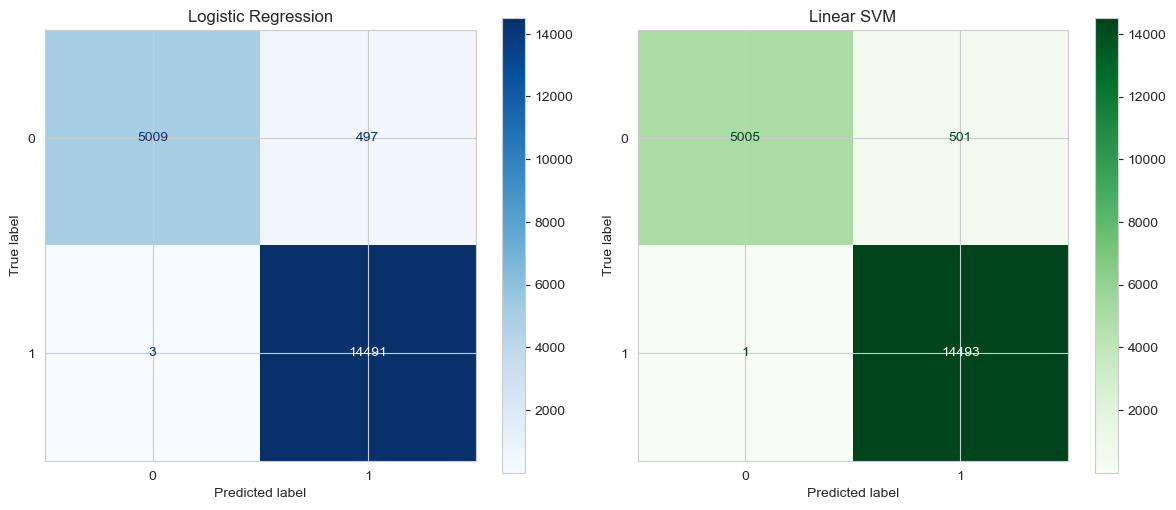

In [131]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred_lr = best_lr.predict(X4_test_std)
y_pred_svm = best_model.predict(X4_test_std)

# Create plots
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y4_test,
    y_pred_lr,
    cmap="Blues",
    ax=ax[0]
)
ax[0].set_title("Logistic Regression")

# Linear SVM
ConfusionMatrixDisplay.from_predictions(
    y4_test,
    y_pred_svm,
    cmap="Greens",
    ax=ax[1]
)
ax[1].set_title("Linear SVM")

plt.tight_layout()
plt.show()

| Metric                | Logistic Regression |  Linear SVM |
| --------------------- | ------------------: | ----------: |
| True Negatives (0→0)  |          **5009** ✅ |        5005 |
| False Positives (0→1) |           **497** ✅ |         501 |
| False Negatives (1→0) |                   3 |     **1** ✅ |
| True Positives (1→1)  |               14491 | **14493** ✅ |


### Confusion Matrix Analysis

The confusion matrices of Logistic Regression and LinearSVC were compared to evaluate their prediction performance.

- Both models achieved very similar classification results.
- Logistic Regression correctly classified slightly more negative samples, while LinearSVC correctly classified slightly more positive samples.
- The overall difference between the two models was very small.
- Logistic Regression was selected as the final model because it provides probability estimates, is easier to interpret, and is widely used in loan approval prediction.

## ROC-AUC Curve

The ROC-AUC curve was used to measure the model's ability to distinguish between approved and rejected loan applications.

#### ROC-AUC Curve

The ROC-AUC curve was used to evaluate and compare the classification performance of the final Logistic Regression and Linear SVM models.

A higher ROC-AUC score indicates better ability to distinguish between approved and rejected loan applications.

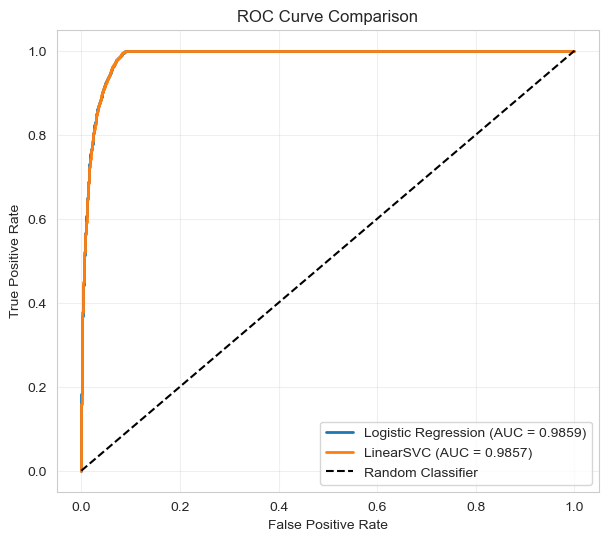

Logistic Regression ROC-AUC : 0.9859
LinearSVC ROC-AUC           : 0.9857


In [138]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression probabilities
y_prob_lr = best_lr.predict_proba(X4_test_std)[:, 1]

# LinearSVC decision scores
y_score_svm = best_model.decision_function(X4_test_std)

# ROC values
fpr_lr, tpr_lr, _ = roc_curve(y4_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y4_test, y_score_svm)

# AUC scores
auc_lr = roc_auc_score(y4_test, y_prob_lr)
auc_svm = roc_auc_score(y4_test, y_score_svm)

# Plot ROC curves
plt.figure(figsize=(7,6))

plt.plot(
    fpr_lr, tpr_lr,
    label=f'Logistic Regression (AUC = {auc_lr:.4f})',
    linewidth=2
)

plt.plot(
    fpr_svm, tpr_svm,
    label=f'LinearSVC (AUC = {auc_svm:.4f})',
    linewidth=2
)

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.show()

print(f"Logistic Regression ROC-AUC : {auc_lr:.4f}")
print(f"LinearSVC ROC-AUC           : {auc_svm:.4f}")

#### ROC-AUC Curve

The ROC-AUC curve was used to compare the classification performance of the final Logistic Regression and LinearSVC models.

A higher ROC-AUC score indicates better ability to distinguish between approved and rejected loan applications. Logistic Regression uses predicted probabilities, while LinearSVC uses decision scores to compute the ROC curve.

#### ROC-AUC Curve

The ROC-AUC curve was used to evaluate the classification performance of the Logistic Regression and LinearSVC models across different decision thresholds.

##### Observation
- Logistic Regression achieved an ROC-AUC score of **0.9859**.
- LinearSVC achieved an ROC-AUC score of **0.9857**.
- Both models demonstrated excellent discrimination between approved and rejected loan applications, with ROC curves close to the top-left corner.
- Logistic Regression achieved a marginally higher AUC and was selected as the final model due to its strong performance, simplicity, and interpretability.

### Precision-Recall Curve

The Precision-Recall Curve was used to evaluate the trade-off between precision and recall across different classification thresholds.

This metric is particularly useful for imbalanced classification problems and helps assess the model's performance in identifying the positive class.

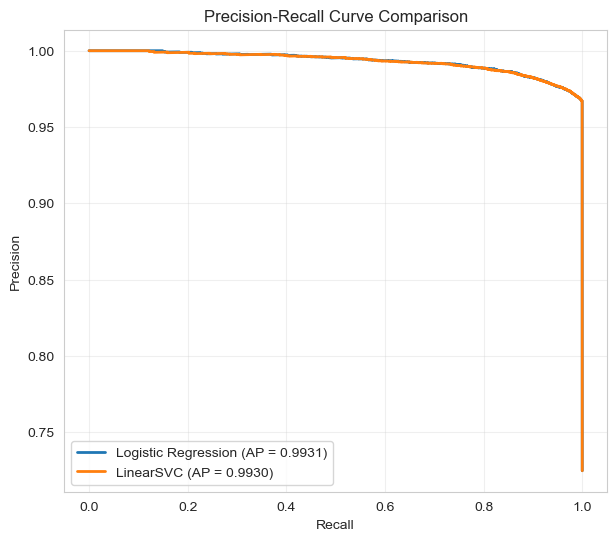

Logistic Regression Average Precision : 0.9931
LinearSVC Average Precision           : 0.9930


In [145]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Logistic Regression probabilities
y_prob_lr = best_lr.predict_proba(X4_test_std)[:, 1]

# LinearSVC decision scores
y_score_svm = best_model.decision_function(X4_test_std)

# Precision-Recall values
precision_lr, recall_lr, _ = precision_recall_curve(y4_test, y_prob_lr)
precision_svm, recall_svm, _ = precision_recall_curve(y4_test, y_score_svm)

# Average Precision (AP)
ap_lr = average_precision_score(y4_test, y_prob_lr)
ap_svm = average_precision_score(y4_test, y_score_svm)

# Plot
plt.figure(figsize=(7,6))

plt.plot(
    recall_lr,
    precision_lr,
    label=f'Logistic Regression (AP = {ap_lr:.4f})',
    linewidth=2
)

plt.plot(
    recall_svm,
    precision_svm,
    label=f'LinearSVC (AP = {ap_svm:.4f})',
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.show()

print(f"Logistic Regression Average Precision : {ap_lr:.4f}")
print(f"LinearSVC Average Precision           : {ap_svm:.4f}")

### Precision-Recall Curve Conclusion

- Logistic Regression achieved an Average Precision (AP) score of **0.9931**, while LinearSVC achieved **0.9930**.
- Both models demonstrated excellent precision-recall performance, indicating strong capability in correctly identifying loan approvals while minimizing misclassifications.
- Since Logistic Regression achieved a marginally higher AP score and offers better interpretability, it was selected as the final model for loan approval prediction.

## Overall Model Evaluation

The final Logistic Regression model demonstrated strong and consistent performance across multiple evaluation metrics.

- The confusion matrix showed that the model correctly classified the majority of loan applications with very few misclassifications.
- The ROC-AUC score indicated excellent discrimination between approved and rejected loan applications.
- The Precision-Recall Curve achieved an Average Precision (AP) score of **0.9931**, demonstrating excellent performance on the imbalanced dataset.
- Five-fold cross-validation confirmed that the model generalizes well to unseen data.
- Hyperparameter tuning resulted in only marginal performance improvements, indicating that the baseline Logistic Regression model was already well optimized.

Overall, the model provides high predictive performance while remaining simple, interpretable, and suitable for real-world loan approval prediction.

# Model Deployment Preparation

The final trained pipeline was saved using Joblib.

The saved model contains:

- Complete preprocessing pipeline
- SMOTE-Tomek transformation
- Logistic Regression model
- Feature configuration

The saved artifact can be directly loaded into deployment applications such as Streamlit without retraining.

In [292]:
import joblib
import os

os.makedirs("artifacts", exist_ok=True)

joblib.dump(
    {
        "model": final_model,
        "feature_names": X4_train.columns.tolist()
    },
    "artifacts/loan_approval_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


## Model Saving

The final Logistic Regression model, along with the fitted scaler and feature names, was saved using the **joblib** library. Saving these artifacts enables the trained model to be reused for future predictions without the need for retraining. This approach follows industry-standard machine learning deployment practices and facilitates seamless integration with applications such as **Streamlit**.

# Project Conclusion

This project developed a machine learning-based Loan Approval Prediction system to assist financial institutions in making accurate and consistent lending decisions. Multiple classification algorithms were evaluated, including Logistic Regression and LinearSVC, to identify the most suitable model for the dataset.

To address class imbalance, the SMOTE-Tomek resampling technique was applied, and model performance was validated using 5-Fold Cross-Validation. Hyperparameter tuning was performed using RandomizedSearchCV to further optimize model performance. The final Logistic Regression model demonstrated strong predictive capability while maintaining simplicity, interpretability, and computational efficiency.

The model was comprehensively evaluated using the Classification Report, Confusion Matrix, ROC-AUC Curve, and Precision-Recall Curve, confirming its ability to generalize well on unseen data. Based on these results, Logistic Regression was selected as the final model for loan approval prediction.

Finally, the trained model, feature scaler, and feature names were saved using the **joblib** library to support future predictions and deployment. These saved artifacts enable seamless integration with applications such as Streamlit without requiring the model to be retrained.

Overall, the developed solution provides a reliable, scalable, and deployment-ready framework for automated loan approval prediction, following industry-standard machine learning practices.

In [ ]:
print(X4_train.columns.tolist())

In [ ]:
import joblib

artifact = joblib.load("artifacts/loan_approval_model.pkl")

print(artifact["feature_names"])

In [ ]:
artifact = joblib.load("artifacts/loan_approval_model.pkl")

print(artifact.keys())

In [ ]:
print(artifact["feature_names"])

In [ ]:
print(type(artifact["scaler"]))

In [ ]:
import os

print(os.listdir("artifacts"))

In [ ]:
import os

print(os.getcwd())


In [156]:
import os

print(os.listdir())

['-1.14-windows.xml', '.anaconda', '.android', '.antigravity', '.aws', '.bash_history', '.cache', '.conda', '.condarc', '.continuum', '.dotnet', '.gemini', '.gitconfig', '.gradle', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.kiro', '.lesshst', '.m2', '.matplotlib', '.nbi', '.skiko', '.streamlit', '.supabase', '.templateengine', '.thumbnails', '.viminfo', '.VirtualBox', '.virtual_documents', '.vscode', '.vscode-shared', 'anaconda3', 'anaconda_projects', 'AndroidStudioProjects', 'AppData', 'Application Data', 'artifacts', 'battery-report.html', 'Bengaluru_House_Data.csv', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'EDAproject.ipynb', 'Favorites', 'hi', 'HOUSE_PRICE_FINAL.ipynb', 'house_price_model.pkl', 'hr.sql', 'kat.py', 'Links', 'loan_classification.csv', 'Loan_Classification.ipynb', 'Local Settings', 'Machine_Learn.ipynb', 'MACHINE_LEARN_1.ipynb', 'ML (HOUSE_PRICE_PREDICTION)', 'ml_part2.ipynb', 'model_columns.pkl', 'Music', 'My Documents', 'my project.ipynb', 'm

In [160]:
import os

print(os.listdir("artifacts"))

['loan_approval_model.pkl']


In [162]:
artifact = joblib.load(
    "artifacts/loan_approval_model.pkl"
)

print(artifact.keys())

dict_keys(['model', 'scaler', 'feature_names'])


In [173]:
print(artifact["feature_names"])

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'LoanAmount', 'Credit_History', 'TotalIncome', 'LoanTermYears', 'LoanIncomeRatio', 'EMI', 'Property_Area_Semiurban', 'Property_Area_Urban']


In [239]:
artifact = joblib.load(
    "artifacts/loan_approval_model.pkl"
)

print(artifact.keys())

dict_keys(['model', 'feature_names'])


In [241]:
print(artifact["model"])

Pipeline(steps=[('scaler', StandardScaler()),
                ('smote', SMOTETomek(random_state=42)),
                ('classifier',
                 LogisticRegression(C=0.162377, max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])


In [243]:
import joblib

artifact = joblib.load(
    r"C:\Users\karth\OneDrive\Desktop\Loan_Approval_Project\artifacts\loan_approval_model.pkl"
)

print(artifact.keys())

print(artifact["model"])

dict_keys(['model', 'scaler', 'feature_names'])
LogisticRegression(C=0.1623776739188721, max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')
